<a href="https://colab.research.google.com/github/MInesGomes/DataScienceObesityLevels/blob/main/DSGroup2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div class="alert alert-block alert-success">
<a id='business'>
<font color = '#006400'>

# 0. Identify Business needs </font>
</a>

</div>
Obesity is one of the most significant global public health challenges of the 21st century. According to the World Health Organization (WHO), it is a primary driver of cardiovascular diseases, type 2 diabetes, and reduced life expectancy. Understanding the behavioral, dietary, and physical factors associated with obesity is critical for designing effective public health policies and personal interventions.
With the increasing availability of lifestyle data, machine learning offers powerful tools to identify complex patterns between daily habits and body mass. By analyzing eating behaviors, physical activity, technology use, and demographics, we can develop data-driven models that uncover meaningful insights into obesity risk factors.

 **Project Objectives**

The primary goal is to understand the relationship between lifestyle behaviors and obesity levels through data exploration and predictive modeling.

*   **Exploratory Analysis:** Identify behavioral patterns and correlations within the dataset.
*   **Predictive Modeling:** Develop and evaluate classification models to predict obesity levels based on lifestyle variables.
*   **Feature Importance:** Determine which habits (e.g., physical activity vs. diet) are the strongest predictors of obesity risk.
*   **Actionable Insights:** Propose recommendations for public health policies and lifestyle interventions.

 **Research Questions**

*   Does physical activity significantly influence obesity classification?
*   Are eating habits stronger predictors of obesity than demographic factors?
*   Is there a measurable relationship between technology usage (screen time) and obesity levels?
*   Do transportation habits (e.g., walking vs. driving) correlate with healthier outcomes?
*   How do obesity patterns vary across different age groups and genders?

 **Dataset Limitations & Future Scope**

While this dataset provides a strong foundation, several critical factors—particularly those related to mental health and socio-economics—are currently unavailable. Future research would benefit from including:

*   **Social Context:** Eating alone vs. with family; screen time allowed during meals.
*   **Home Environment:** Single-parent households or household size.
*   **Work-Life Balance:** Long commute times leading to "cooking fatigue" and reliance on convenience foods.
*   **Dietary Specifics:** Granular data on fast food frequency and meat consumption.
*   **Geographic Diversity:** Data from a wider variety of regions and cultures.

**Project Repository:** [GitHub - Data Science Obesity Levels](https://github.com/MInesGomes/DataScienceObesityLevels)


<div class="alert alert-block alert-success">
<a id='toc'>
<font color = '#006400'>

# TABLE OF CONTENTS </font>
</a>

- [0. Identify Business needs](#business)
- [1. Import Data](#import)
- [2. Explore Data](#explore)
  - [2.1. Basic Exploration](#basic)
  - [2.2. Statistical Exploration & encoding](#stats)
    - [2.2.1. Numerical Variables](#stats_num)
    - [2.2.2. Categorical Variables (Binary)](#stats_cat)
    - [2.2.3. Ordinal Encoding](#stats_ord)
    - [2.3.4. Create Dummy variables for Means of Transportation](#dummy)
  - [2.3. Visual Exploration](#visual)
- [3. Data Preprocess](#preprocess)
  - [3.1. Skewness and kurtosis](#skew)
  - [3.2 Outlier Detection and Removal](#outlier_detection)
  - [3.3. Create new variables](#new)
  - [3.4. Scaling](#scale)
- [4. In-depth Exploration](#depth)
  - [4.1. Do physical activity levels significantly influence obesity classification?](#inDepht_1)
  - [4.2. Are eating habits stronger predictors of obesity than demographic factors?](#inDepht_2)
  - [4.3. Is there a relationship between technology usage (screen time) and obesity levels?](#inDepht_3)
  - [4.4. Do transportation habits correlate with healthier lifestyles?](#inDepht_4)
  - [4.5. Can obesity patterns vary across age groups and genders?](#inDepht_5)
- [5. Predictive Modeling](#predictive_modeling)
  - [5.1 Logistic Regression](#clean)
  - [5.2 Random Forest to confirm the most important predictors](#clean)
  - [5.3 Decision Trees - IN PROGRESS (Annamaria)](#clean)
  - [5.4 Support Vector Machine (SVM) model](#clean)
  - [5.5 K-Nearest Neighbors](#clean)
  - [5.6 Gradient Boosting methods](#clean)
- [6. Explainable AI](#explain)
</div>

<div class="alert alert-block alert-success">
<a id='import'>
<font color = '#006400'>
    
#1. Import Data </font>
</a>

**Importing dataset from github repository**
https://raw.githubusercontent.com/MInesGomes/DataScienceObesityLevels/main/ObesityDataSet_raw_and_data_sinthetic.csv
    
</div>



In [1]:
import pandas as pd
import numpy as np

# Df = pd.read_csv('/content/ObesityDataSet_raw_and_data_sinthetic.csv')
githubUrl = 'https://raw.githubusercontent.com/MInesGomes/DataScienceObesityLevels/main/ObesityDataSet_raw_and_data_sinthetic.csv'
df = pd.read_csv(githubUrl)

print("\nDataset info:")
print(df.info())
print("\nFirst 5 rows of the dataset:")
display(df.head())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


<div class="alert alert-block alert-success">
<a id='explore'>
<font color = '#006400'>
    
# 2. Explore Data </font>
</a>

**Exploring Dataset, identifying possible problems and errors, identifying outliers and getting major insights**
    
[BACK TO TOC](#toc)    
</div>


<div class="alert alert-block alert-warning">

<a id='basic'></a>

## 2.1. Basic Exploration
    
</div>

 The dataset contains 2111 entries and 17 columns. (8 numeric, 9 categorical)

 There are no missing values in any of the columns, as indicated by the 'Non-Null Count'.

 Is also difficult to find duplicates due to inexistence of person unique identifier.

**Columns datatypes (and name changes for clear understanding ):**
* **Numeric:**
  * Age
  * Height
  * Weigh
  * FreVeg (FCVC) - Frequency of vegetable consumption during meals
  * NumMeals (NCP) - Number of main meals consumed daily
  * WaterCons (CH2O) - Amount of water consumed daily
  * FrePhyAc (FAF) - Frequency of physical activity
  * TimeUseTech (TUE) - Time spent using technological devices (e.g., smartphone, computer, television, videogames)
   
* **Categorical binary  (We'l set value 1 if)**:
  * Gender -  Male
  * FamHist -   has a family history with overweight
  * FreHighCal (FAVC) -  the individual frequently consumes high-calorie food
  * Smoke (SMOKE) - the individual smokes
  * MonitorDailyCal (SCC) - the individual monitors daily calorie intake

* **Categorical:**
  *Ordinal
    * FreBetweenMeals (CAEC) - Frequency of food consumption between meals
    * FreAlcCons (CALC) - Frequency of alcohol consumption
    * Nominal
    * MTransp (MTRANS) - Primary mode of transportation used
* **Categorical ordinal**:  TargetObesityL (NObeyesdad )



In [2]:
# Renaming the columns for clear understanding
RenameMap = {
  'FCVC': 'FreVeg',
  'NCP': 'NumMeals',
  'CH2O': 'WaterCons',
  'FAF': 'FrePhyAc',
  'TUE': 'TimeUseTech',
  'family_history_with_overweight': 'FamHist',
  'FAVC': 'FreHighCal',
  'SMOKE': 'Smoke',
  'SCC': 'MonitorDailyCal',
  'CAEC': 'FreBetweenMeals',
  'CALC': 'FreAlcCons',
  'MTRANS': 'MTransp',
  'NObeyesdad': 'TargetObesityL'
}
display(df.columns)
df = df.rename(columns=RenameMap)

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

In [3]:
# Creating a dictionary of the variables to plot the description
VariableDescription = dict( [
    ("FreVeg", "Frequency of vegetable consumption during meals"),
    ("NumMeals", "Number of main meals consumed daily"),
    ("WaterCons", "Amount of water consumed daily"),
    ("FrePhyAc", "Frequency of physical activity"),
    ("TimeUseTech", "Time spent using technological devices"),
    ("FamHist", "has a family history with overweight"),
    ("FreHighCal", "the individual frequently consumes high-calorie food"),
    ("Smoke", "the individual smokes"),
    ("MonitorDailyCal", "the individual monitors daily calorie intake"),
    ("FreBetweenMeals", "Frequency of food consumption between meals"),
    ("FreAlcCons", "Frequency of alcohol consumption"),
    ("MTransp", "Primary mode of transportation used")
])

print(VariableDescription)

{'FreVeg': 'Frequency of vegetable consumption during meals', 'NumMeals': 'Number of main meals consumed daily', 'WaterCons': 'Amount of water consumed daily', 'FrePhyAc': 'Frequency of physical activity', 'TimeUseTech': 'Time spent using technological devices', 'FamHist': 'has a family history with overweight', 'FreHighCal': 'the individual frequently consumes high-calorie food', 'Smoke': 'the individual smokes', 'MonitorDailyCal': 'the individual monitors daily calorie intake', 'FreBetweenMeals': 'Frequency of food consumption between meals', 'FreAlcCons': 'Frequency of alcohol consumption', 'MTransp': 'Primary mode of transportation used'}


<div class="alert alert-block alert-warning">

<a id='stats'></a>

## 2.2. Statistical Exploration & encoding
    
</div>

<div class="alert alert-block alert-info">

<a id='stats_num'></a>
### 2.2.1. Numerical Variables
</div>

**Dataset: dfNumVar**

In [4]:
print("\n Describe numerical variables")
dfNumVar=df.describe().T
display(dfNumVar)


 Describe numerical variables


,count,mean,std,min,25%,50%,75%,max
Age,2111.0,24.312600,6.345968,14.00,19.947192,22.777890,26.000000,61.00
Height,2111.0,1.701677,0.093305,1.45,1.630000,1.700499,1.768464,1.98
Weight,2111.0,86.586058,26.191172,39.00,65.473343,83.000000,107.430682,173.00
FreVeg,2111.0,2.419043,0.533927,1.00,2.000000,2.385502,3.000000,3.00
NumMeals,2111.0,2.685628,0.778039,1.00,2.658738,3.000000,3.000000,4.00
WaterCons,2111.0,2.008011,0.612953,1.00,1.584812,2.000000,2.477420,3.00
FrePhyAc,2111.0,1.010298,0.850592,0.00,0.124505,1.000000,1.666678,3.00
TimeUseTech,2111.0,0.657866,0.608927,0.00,0.000000,0.625350,1.000000,2.00


From the above table, we can get these conclusions:
- `count`- All variable have 2111 values. So no missing values.
- `weight`
  - `mean`- The mean weight is 86.58kg.
  - `50%`- Half of the population analysed has 83kg
  - `max`- And the max is 173kg. (Not sure if this value is an outlier.)
- `min`- The minimum time of technology used is 0. Not sure if it's valid.
- `max`- The age group is between 14 and 61 years old.

We can also analyse:
- skewness
- kurtosis.
- And see relation between people who monitor calories intake with accuracy vegatables intake.

<div class="alert alert-block alert-info">
    
<a id='stats_cat'></a>

### 2.2.2. Categorical Variables (Binary)
Encode binary variables change object to int with (0 and 1 values)
</div>

**Dataset: dfCat**

In [5]:
print("\n Describe categorical variables")
df.describe(include = ['O'])


 Describe categorical variables


,Gender,FamHist,FreHighCal,FreBetweenMeals,Smoke,MonitorDailyCal,FreAlcCons,MTransp,TargetObesityL
count,2111,2111,2111,2111,2111,2111,2111,2111,2111
unique,2,2,2,4,2,2,4,5,7
top,Male,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,1726,1866,1765,2067,2015,1401,1580,351


Should we drop these variables?
- `Smoke` - Has only 44 people.
- `MonitorDailyCal` Has only 96 values.

`Public_Transportation` Has the majority of the values for mode of Transportation.

These columns have binaries types but are encoded as object: ['Gender', 'FamHist', 'FreHighCal', 'Smoke', 'MonitorDailyCal']

**Converting from `object` to `int` datatype:** (`0` and `1` values):

In [6]:
# Initialize dfCat as a copy of df to store binary encoded columns
dfCat = df.copy()

# Encoding binary categorical columns
dfCat['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
dfCat['FamHist'] = df['FamHist'].map({'no': 0, 'yes': 1})
dfCat['FreHighCal'] = df['FreHighCal'].map({'no': 0, 'yes': 1})
dfCat['Smoke'] = df['Smoke'].map({'no': 0, 'yes': 1})
dfCat['MonitorDailyCal'] = df['MonitorDailyCal'].map({'no': 0, 'yes': 1})

# List of binary columns to convert to integer type
BinaryCols = ['Gender', 'FamHist', 'FreHighCal', 'Smoke', 'MonitorDailyCal']

# Convert the specified binary columns to integer type in dfCat
for Col in BinaryCols:
    dfCat[Col] = dfCat[Col].astype(int)
display(dfCat.info())

print("DataFrame after encoding binary columns:")
display(dfCat.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           2111 non-null   int64  
 1   Age              2111 non-null   float64
 2   Height           2111 non-null   float64
 3   Weight           2111 non-null   float64
 4   FamHist          2111 non-null   int64  
 5   FreHighCal       2111 non-null   int64  
 6   FreVeg           2111 non-null   float64
 7   NumMeals         2111 non-null   float64
 8   FreBetweenMeals  2111 non-null   object 
 9   Smoke            2111 non-null   int64  
 10  WaterCons        2111 non-null   float64
 11  MonitorDailyCal  2111 non-null   int64  
 12  FrePhyAc         2111 non-null   float64
 13  TimeUseTech      2111 non-null   float64
 14  FreAlcCons       2111 non-null   object 
 15  MTransp          2111 non-null   object 
 16  TargetObesityL   2111 non-null   object 
dtypes: float64(8),

None

DataFrame after encoding binary columns:


,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBetweenMeals,Smoke,WaterCons,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,MTransp,TargetObesityL
0,0,21.0,1.62,64.0,1,0,2.0,3.0,Sometimes,0,2.0,0,0.0,1.0,no,Public_Transportation,Normal_Weight
1,0,21.0,1.52,56.0,1,0,3.0,3.0,Sometimes,1,3.0,1,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,1,23.0,1.80,77.0,1,0,2.0,3.0,Sometimes,0,2.0,0,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,1,27.0,1.80,87.0,0,0,3.0,3.0,Sometimes,0,2.0,0,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,1,22.0,1.78,89.8,0,0,2.0,1.0,Sometimes,0,2.0,0,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


<div class="alert alert-block alert-info">
    
<a id='stats_ord'></a>

### 2.2.3. Ordinal Encoding
    
</div>

**Dataset: dfOrdinalEnc**

For the ordinal variables `FreBetweenMeals` and `FreAlcCons`, we'll  apply ordinal encoding to maintain the order of Frequency between meals.

The columns will be ordinally encoded intothe following numerical values:

* 'no' is encoded as 0.0
* 'Sometimes' is encoded as 1.0
* 'Frequently' is encoded as 2.0
* 'Always' is encoded as 3.0

In [7]:
# Show counts for categorical features
dfOrdinalEnc=dfCat.copy()
for Col in dfOrdinalEnc.select_dtypes(include='object').columns:
    print("\n ", dfOrdinalEnc[Col].value_counts())


  FreBetweenMeals
Sometimes     1765
Frequently     242
Always          53
no              51
Name: count, dtype: int64

  FreAlcCons
Sometimes     1401
no             639
Frequently      70
Always           1
Name: count, dtype: int64

  MTransp
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7
Name: count, dtype: int64

  TargetObesityL
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


In [8]:
from sklearn.preprocessing import OrdinalEncoder

# Define the order for 'FreBetweenMeals' and 'FreAlcCons'
FreBetweenMealsOrder = ['no', 'Sometimes', 'Frequently', 'Always']

# Initialize the OrdinalEncoder with the specified categories
EncoderFbm = OrdinalEncoder(categories=[FreBetweenMealsOrder])

# Apply ordinal encoding to the 'FreBetweenMeals' column
dfOrdinalEnc['FreBetweenMeals'] = EncoderFbm.fit_transform(dfOrdinalEnc[['FreBetweenMeals']])
dfOrdinalEnc['FreAlcCons'] = EncoderFbm.fit_transform(dfOrdinalEnc[['FreAlcCons']])

print("\nDataFrame after ordinal encoding 'FreBetweenMeals' and 'FreAlcCons':")
display(dfOrdinalEnc.head())
print("\nUnique encoded values for:")
print(dfOrdinalEnc['FreBetweenMeals'].value_counts())
print(dfOrdinalEnc['FreAlcCons'].value_counts())


DataFrame after ordinal encoding 'FreBetweenMeals' and 'FreAlcCons':


,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBetweenMeals,Smoke,WaterCons,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,MTransp,TargetObesityL
0,0,21.0,1.62,64.0,1,0,2.0,3.0,1.0,0,2.0,0,0.0,1.0,0.0,Public_Transportation,Normal_Weight
1,0,21.0,1.52,56.0,1,0,3.0,3.0,1.0,1,3.0,1,3.0,0.0,1.0,Public_Transportation,Normal_Weight
2,1,23.0,1.80,77.0,1,0,2.0,3.0,1.0,0,2.0,0,2.0,1.0,2.0,Public_Transportation,Normal_Weight
3,1,27.0,1.80,87.0,0,0,3.0,3.0,1.0,0,2.0,0,2.0,0.0,2.0,Walking,Overweight_Level_I
4,1,22.0,1.78,89.8,0,0,2.0,1.0,1.0,0,2.0,0,0.0,0.0,1.0,Public_Transportation,Overweight_Level_II



Unique encoded values for:
FreBetweenMeals
1.0    1765
2.0     242
3.0      53
0.0      51
Name: count, dtype: int64
FreAlcCons
1.0    1401
0.0     639
2.0      70
3.0       1
Name: count, dtype: int64


The `value_counts()` output for the remaining categorical features (`FreBetweenMeals`, `FreAlcCons`, and `MTransp`) shows the following:

*   **`FreBetweenMeals` (Frequency of food consumption between meals):**
    *   The vast majority of individuals (`1765`) consume food **'Sometimes'** between meals.
    *   A smaller group (`242`) does so **'Frequently'**.
    *   Very few (`53`) consume food **'Always'** between meals, and an even smaller number (`51`) **'no'** food between meals.

*   **`FreAlcCons` (Frequency of alcohol consumption):**
    *   Most individuals (`1401`) consume alcohol **'Sometimes'**.
    *   A significant portion (`639`) consume **'no'** alcohol.
    *   Only a small number (`70`) consume alcohol **'Frequently'**.
    *   Only `1` individual consumes alcohol **'Always'**, which was identified as a potential **outlier earlier.**

*   **`MTransp` (Primary mode of transportation used):**
    *   The overwhelming majority (`1580`) use **'Public_Transportation'**.
    *   **'Automobile'** is the second most common mode (`457`).
    *   **'Walking'** is used by a much smaller group (`56`).
    *   **'Motorbike'** (`11`) and **'Bike'** (`7`) are very rarely used, suggesting these categories might have limited predictive power due to their low frequency.


For the target variable `TargetObesityL`, we'll also apply ordinal encoding to maintain the order of obesity levels.

**Dataset: dfTargetEnc**

In [9]:
dfTargetEnc = dfOrdinalEnc.copy()

# Define the order of the obesity levels
ObesityOrder = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]

# Initialize the OrdinalEncoder with the specified categories
Encoder = OrdinalEncoder(categories=[ObesityOrder])

# Apply ordinal encoding to the 'TargetObesityL' column
dfTargetEnc['TargetObesityL'] = Encoder.fit_transform(dfTargetEnc[['TargetObesityL']])

print("\nDataFrame after ordinal encoding 'TargetObesityL':")
display(dfTargetEnc.head())
print("\nUnique encoded values for 'TargetObesityL':")
print(dfTargetEnc['TargetObesityL'].value_counts())


DataFrame after ordinal encoding 'TargetObesityL':


,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBetweenMeals,Smoke,WaterCons,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,MTransp,TargetObesityL
0,0,21.0,1.62,64.0,1,0,2.0,3.0,1.0,0,2.0,0,0.0,1.0,0.0,Public_Transportation,1.0
1,0,21.0,1.52,56.0,1,0,3.0,3.0,1.0,1,3.0,1,3.0,0.0,1.0,Public_Transportation,1.0
2,1,23.0,1.80,77.0,1,0,2.0,3.0,1.0,0,2.0,0,2.0,1.0,2.0,Public_Transportation,1.0
3,1,27.0,1.80,87.0,0,0,3.0,3.0,1.0,0,2.0,0,2.0,0.0,2.0,Walking,2.0
4,1,22.0,1.78,89.8,0,0,2.0,1.0,1.0,0,2.0,0,0.0,0.0,1.0,Public_Transportation,3.0



Unique encoded values for 'TargetObesityL':
TargetObesityL
4.0    351
6.0    324
5.0    297
2.0    290
3.0    290
1.0    287
0.0    272
Name: count, dtype: int64


<div class="alert alert-block alert-info">
    
<a id='dummy'></a>

### 2.3.4. Create Dummy variables for Means of Transportation
    
</div>

In [10]:
dfClean = dfTargetEnc.copy()
# One-hot encoding for multi-category nominal features
NominalCols = ['MTransp']
# dfHot = pd.get_dummies(dfTransformed, columns=NominalCols, drop_first=True, dtype=int)
dfClean = pd.get_dummies(dfClean, columns=NominalCols, drop_first=False, dtype=int)

print("\nDataFrame after one-hot encoding:")
display(dfClean)


DataFrame after one-hot encoding:


,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBetweenMeals,Smoke,...,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,TargetObesityL,MTransp_Automobile,MTransp_Bike,MTransp_Motorbike,MTransp_Public_Transportation,MTransp_Walking
0,0,21.000000,1.620000,64.000000,1,0,2.0,3.0,1.0,0,...,0,0.000000,1.000000,0.0,1.0,0,0,0,1,0
1,0,21.000000,1.520000,56.000000,1,0,3.0,3.0,1.0,1,...,1,3.000000,0.000000,1.0,1.0,0,0,0,1,0
2,1,23.000000,1.800000,77.000000,1,0,2.0,3.0,1.0,0,...,0,2.000000,1.000000,2.0,1.0,0,0,0,1,0
3,1,27.000000,1.800000,87.000000,0,0,3.0,3.0,1.0,0,...,0,2.000000,0.000000,2.0,2.0,0,0,0,0,1
4,1,22.000000,1.780000,89.800000,0,0,2.0,1.0,1.0,0,...,0,0.000000,0.000000,1.0,3.0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,0,20.976842,1.710730,131.408528,1,1,3.0,3.0,1.0,0,...,0,1.676269,0.906247,1.0,6.0,0,0,0,1,0
2107,0,21.982942,1.748584,133.742943,1,1,3.0,3.0,1.0,0,...,0,1.341390,0.599270,1.0,6.0,0,0,0,1,0
2108,0,22.524036,1.752206,133.689352,1,1,3.0,3.0,1.0,0,...,0,1.414209,0.646288,1.0,6.0,0,0,0,1,0
2109,0,24.361936,1.739450,133.346641,1,1,3.0,3.0,1.0,0,...,0,1.139107,0.586035,1.0,6.0,0,0,0,1,0


In [11]:
dfClean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Gender                         2111 non-null   int64  
 1   Age                            2111 non-null   float64
 2   Height                         2111 non-null   float64
 3   Weight                         2111 non-null   float64
 4   FamHist                        2111 non-null   int64  
 5   FreHighCal                     2111 non-null   int64  
 6   FreVeg                         2111 non-null   float64
 7   NumMeals                       2111 non-null   float64
 8   FreBetweenMeals                2111 non-null   float64
 9   Smoke                          2111 non-null   int64  
 10  WaterCons                      2111 non-null   float64
 11  MonitorDailyCal                2111 non-null   int64  
 12  FrePhyAc                       2111 non-null   f

<div class="alert alert-block alert-warning">

<a id='visual'></a>

## 2.3. Visual Exploration
    
</div>    


Checking the distribution of the numeric variables using a `histplot()`. Define the color as green and the number of bins equal to 30.

**Dataset: dfClean**

In [12]:
# Function to plot an Histograms and boxplot's from the numeric variables
# of the dataset `df_plot` in `num_cols` columns
from matplotlib.colors import ColorSequenceRegistry
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

HIST_PLOT ='Histograms'
BOX_PLOT= 'Box Plot'

# Function to plot a type of chart from the dataset DfPlot in `NumCols` columns
def numericColumnsPlot(DfPlot, NumCols = 3, TypePlot= HIST_PLOT, KdeValue=False, BinValue=20):
  DfPlotDesc= DfPlot.rename(columns=VariableDescription)
  NumericCols = DfPlotDesc.columns[DfPlotDesc.dtypes != 'object'].tolist()

  # Exclude target variable if it's numerical and we don't want to plot it here
  if 'TargetObesityL' in NumericCols:
      NumericCols.remove('TargetObesityL')
  # if 'NObeyesdad' in NumericCols:
  #     NumericCols.remove('NObeyesdad')

  # Calculate the number of rows and columns needed for the subplots
  NumPlots = len(NumericCols)
  NumRows = math.ceil(NumPlots / NumCols)

  # Create subplots dynamically based on the number of numerical columns
  Fig, Axes = plt.subplots(NumRows, NumCols, figsize=(5 * NumCols, 4 * NumRows))
  Axes = Axes.flatten() # Flatten the 2D array of Axes for easy iteration

  Color=sns.color_palette("hls", NumPlots)

  # Plot histograms for each numerical column
  for i, Col in enumerate(NumericCols):
      # if TypePlot==PAIR_PLOT:
      if (TypePlot==HIST_PLOT):
        sns.histplot(data=DfPlotDesc, kde=KdeValue, x=Col, color=Color[i], bins=BinValue, ax=Axes[i])
      else:
        sns.boxplot(ax = Axes[i], data = DfPlotDesc, x = Col, color=Color[i])
      Axes[i].set_title('                         ')
      Axes[i].set_xlabel(Col)
      Axes[i].set_ylabel('')

  # Remove any unused subplots if NumPlots is not a multiple of NumCols
  for j in range(i + 1, len(Axes)): # i is the last index used for plotting
      Fig.delaxes(Axes[j])

  plt.tight_layout()
  plt.suptitle(f'{TypePlot} of Numerical Variables', y=1.02, fontsize=16)
  plt.show()
  plt.savefig(f'{TypePlot} of Numerical Variables{NumCols}.png')

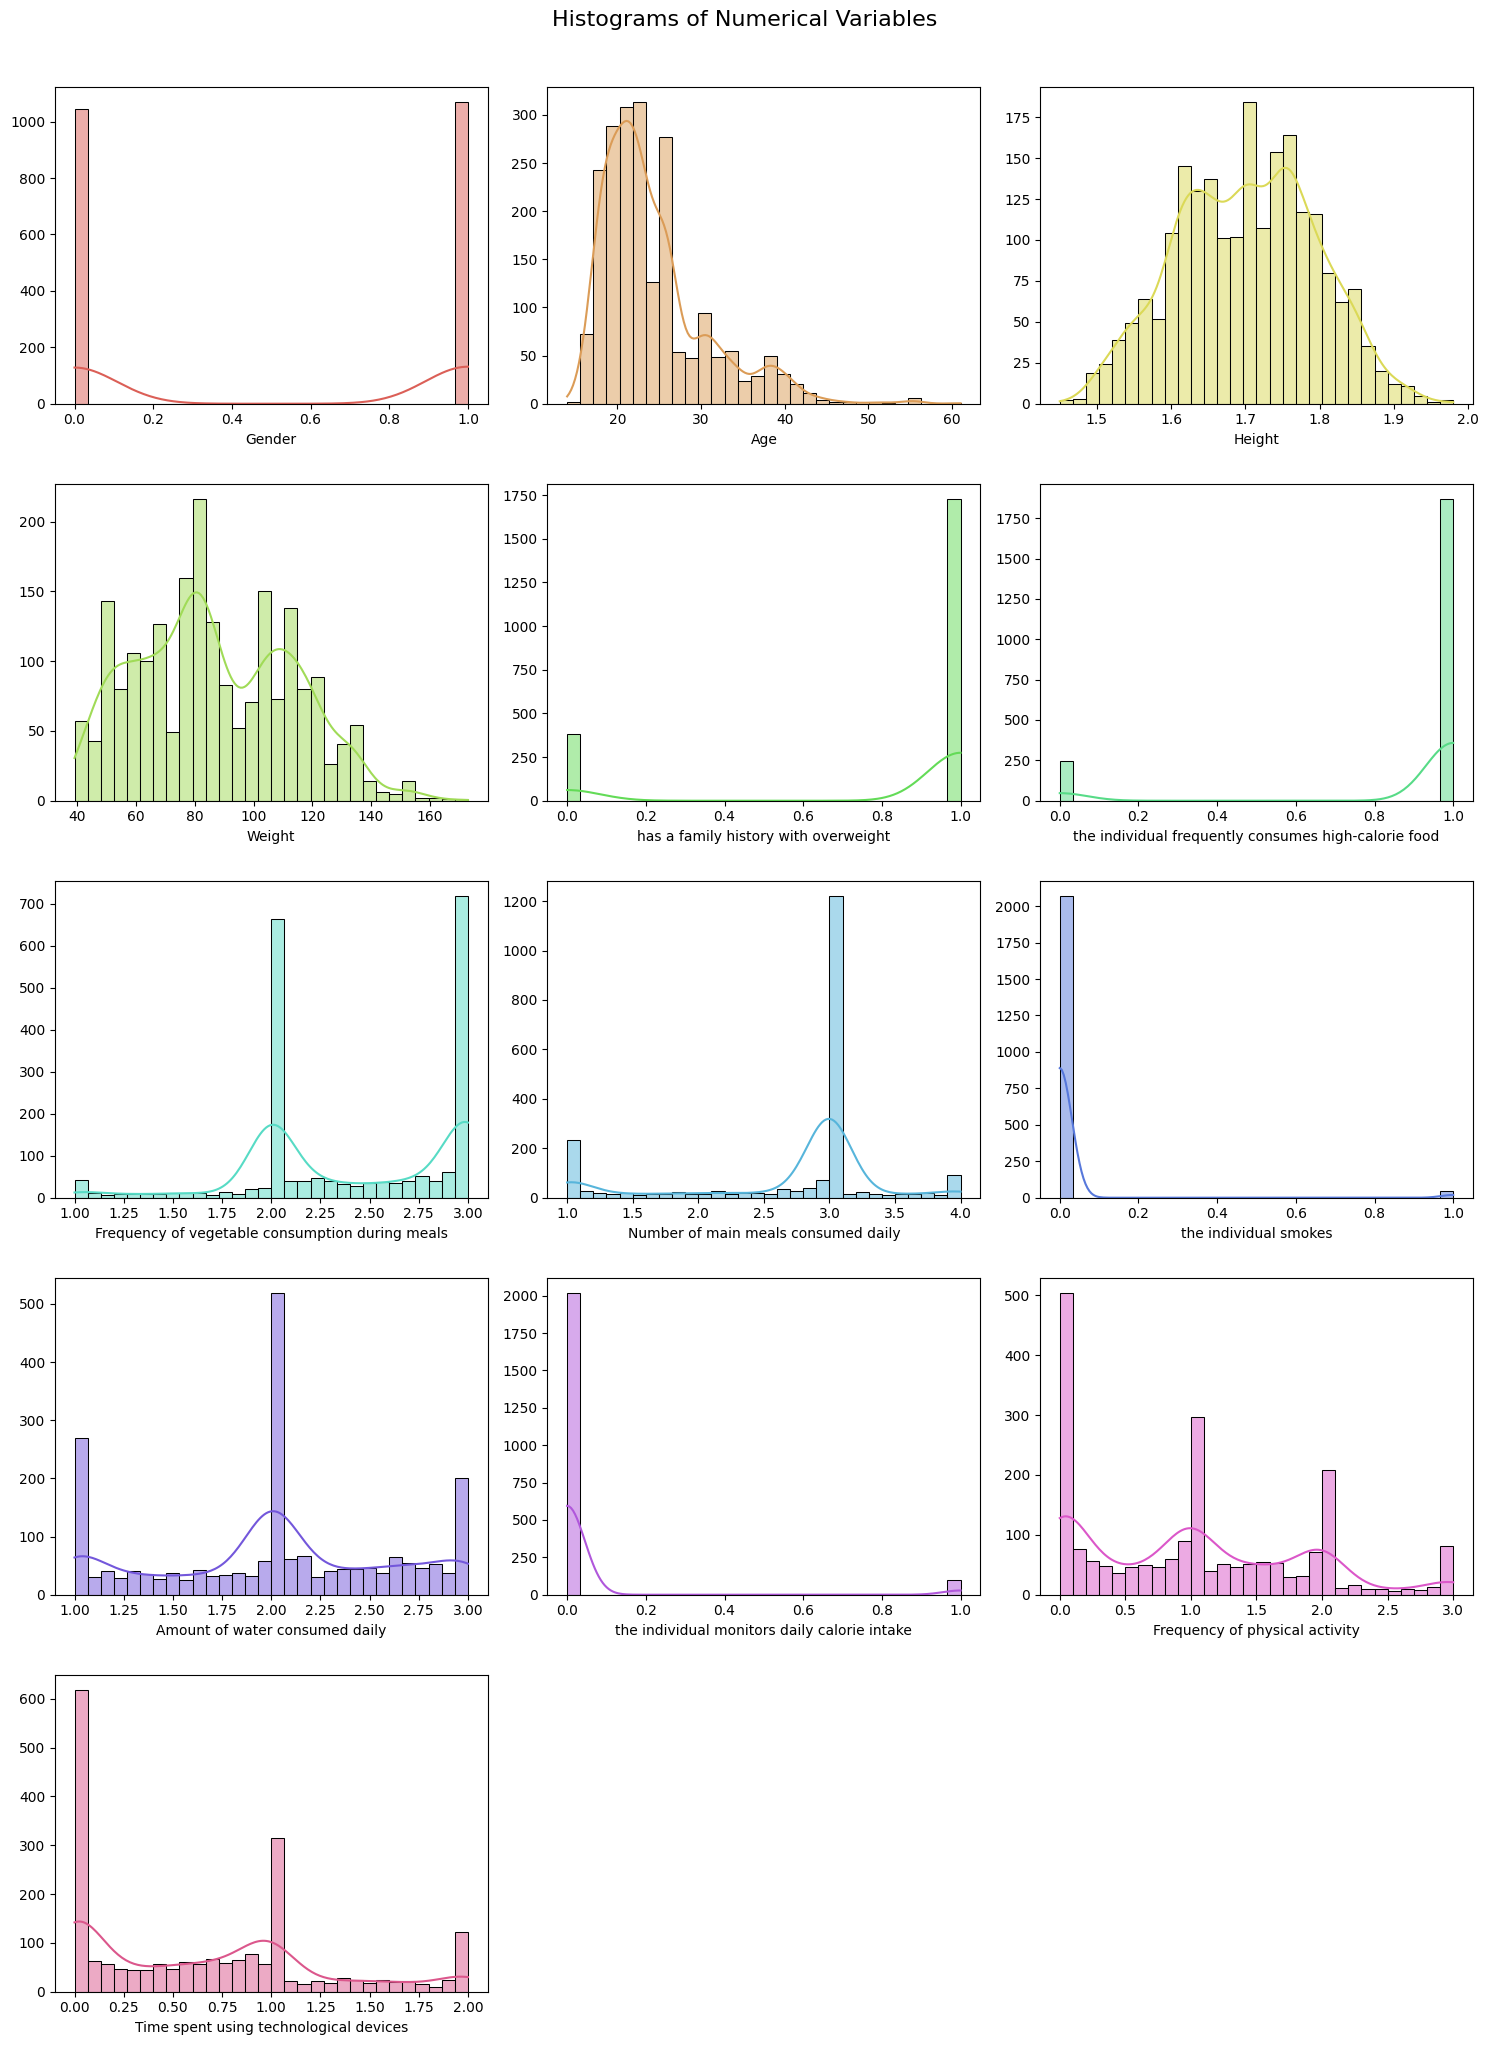

<Figure size 640x480 with 0 Axes>

In [13]:
# numericColumnsPlot(dfClean, 3,HIST_PLOT,True, 30)
numericColumnsPlot(dfCat, 3,HIST_PLOT,True, 30)

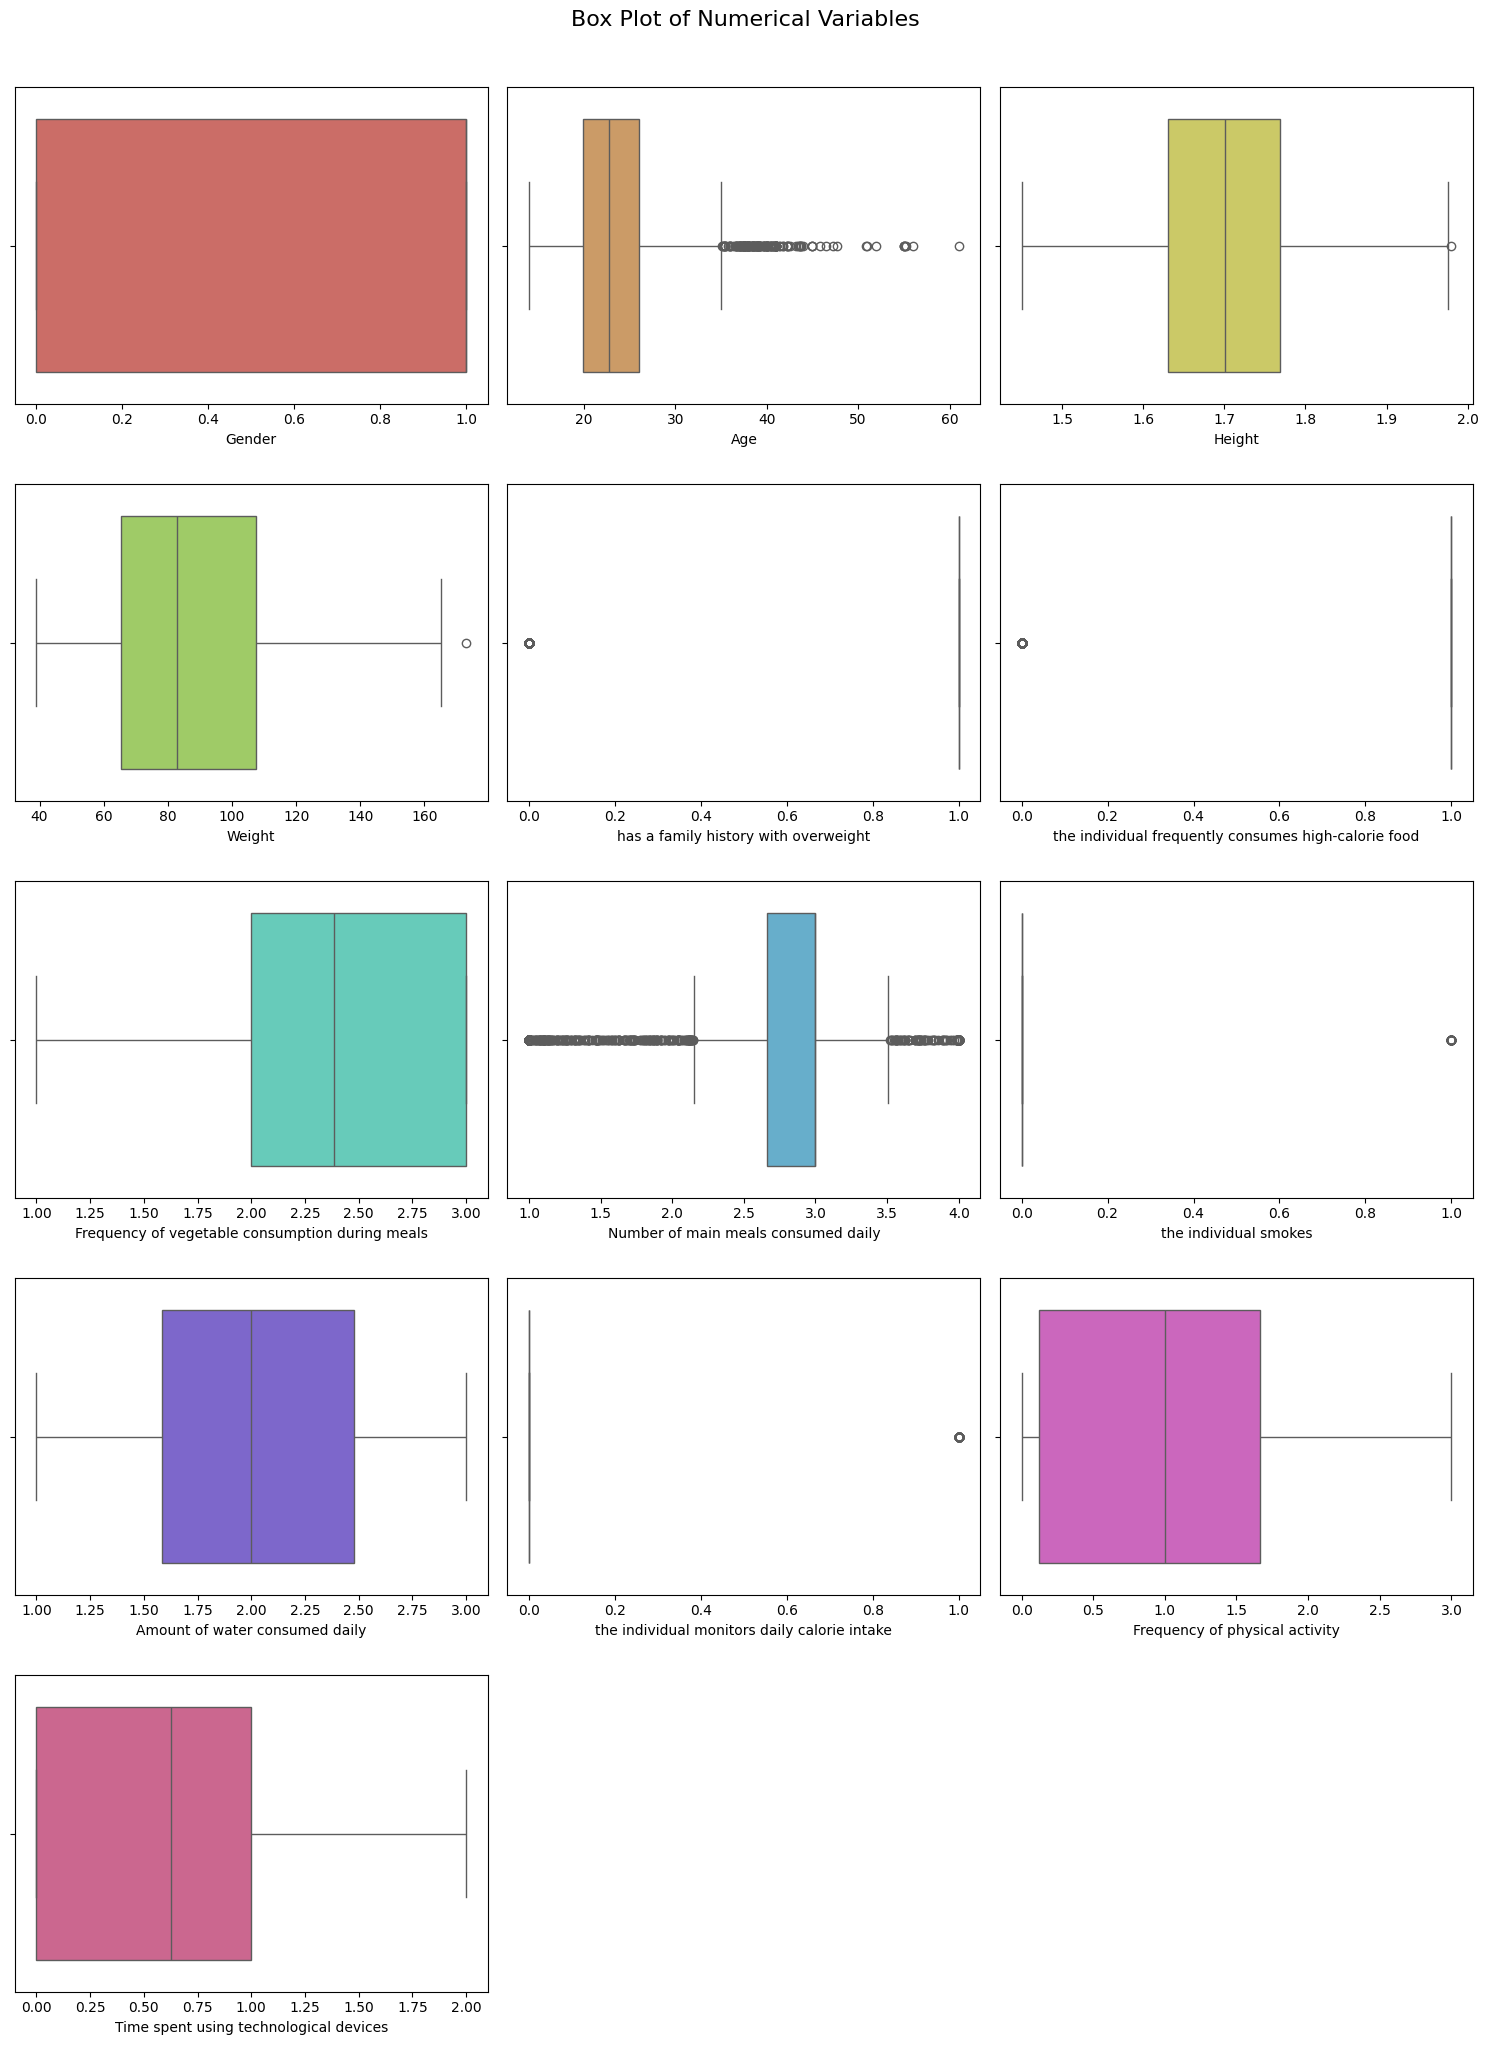

<Figure size 640x480 with 0 Axes>

In [14]:
# numericColumnsPlot(dfClean, 3, BOX_PLOT )
numericColumnsPlot(dfCat, 3, BOX_PLOT )

<Axes: >

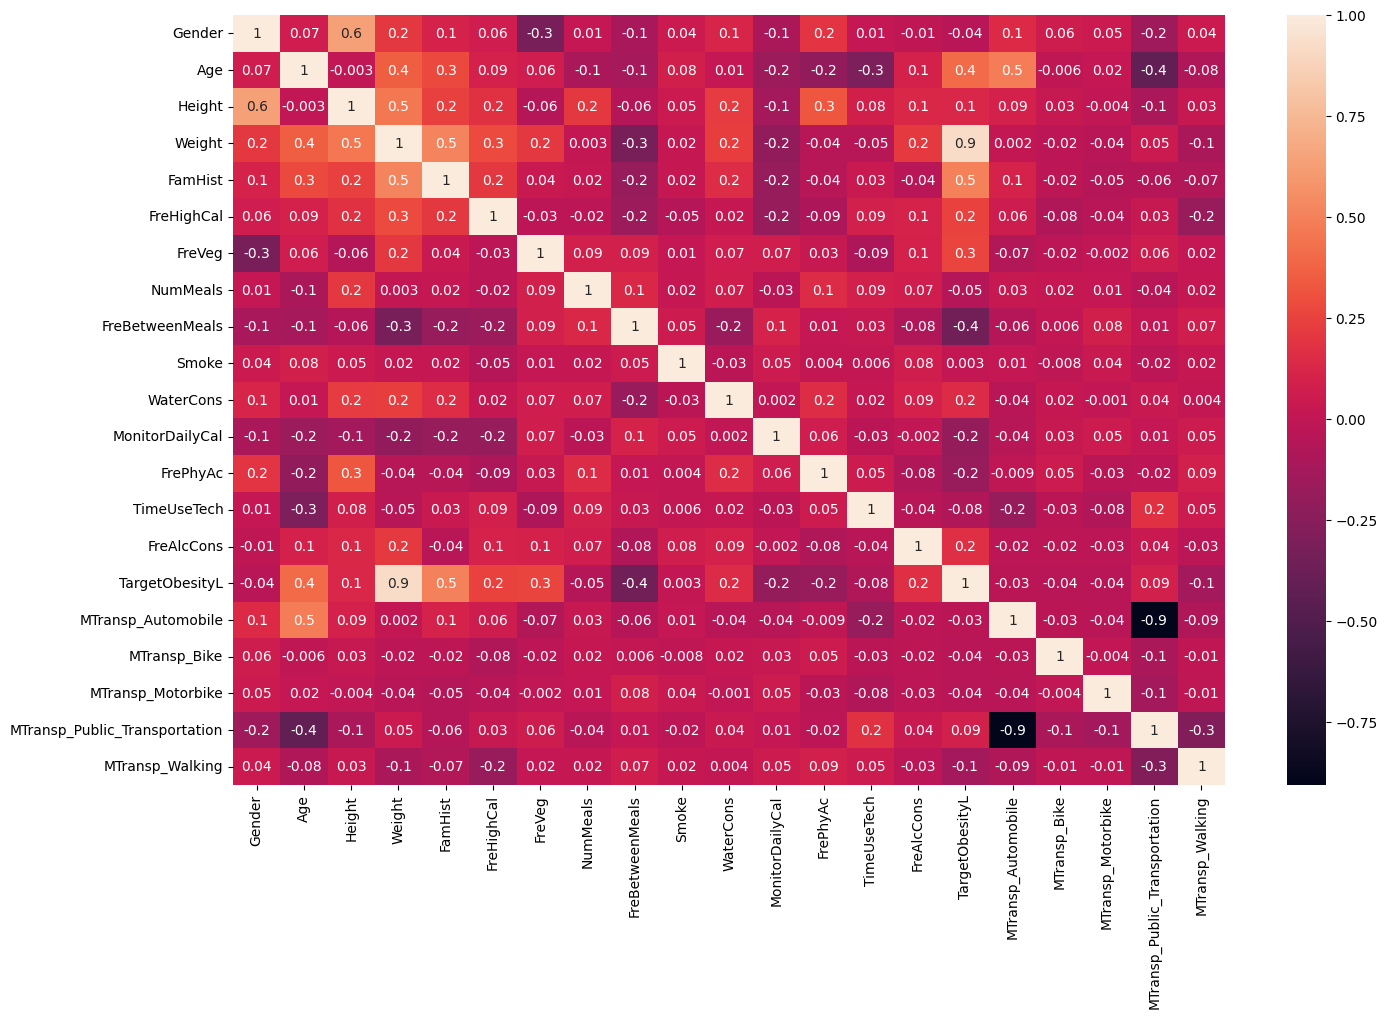

In [15]:
dfCorr = dfClean.corr(method = 'spearman', numeric_only=True)
Figure = plt.figure(figsize=(16,10))
sns.heatmap(dfCorr, annot=True, fmt = '.1g')

Text(0, 0.5, '')

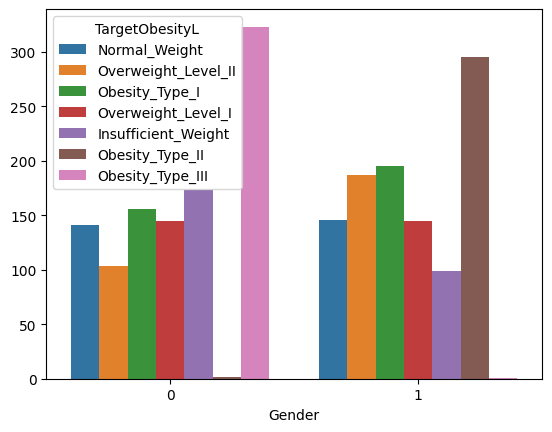

In [16]:
sns.countplot(x = 'Gender', hue = 'TargetObesityL', data = dfCat)
plt.ylabel('')

In [17]:
dfClean.query('Gender == 0').groupby('TargetObesityL')['Age'].mean()

,Age
TargetObesityL,
0.0,20.507997
1.0,22.028369
2.0,24.578058
3.0,27.389479
4.0,27.894942
5.0,24.500000
6.0,23.512568


In [18]:
dfClean.query('Gender == 0').groupby('TargetObesityL')['Age'].median()

,Age
TargetObesityL,
0.0,19.880360
1.0,21.000000
2.0,21.455463
3.0,25.113537
4.0,23.000000
5.0,24.500000
6.0,25.427240


<div class="alert alert-block alert-success">
<a id='preprocess'>
<font color = '#006400'>
    
#3. Data Preprocess  </font>
</a>

    
[BACK TO TOC](#toc)    
</div>


In [19]:
print("\n Describe variables")
NumVar=dfClean.describe().T
display(NumVar)


 Describe variables


,count,mean,std,min,25%,50%,75%,max
Gender,2111.0,0.505921,0.500083,0.00,0.000000,1.000000,1.000000,1.00
Age,2111.0,24.312600,6.345968,14.00,19.947192,22.777890,26.000000,61.00
Height,2111.0,1.701677,0.093305,1.45,1.630000,1.700499,1.768464,1.98
Weight,2111.0,86.586058,26.191172,39.00,65.473343,83.000000,107.430682,173.00
FamHist,2111.0,0.817622,0.386247,0.00,1.000000,1.000000,1.000000,1.00
FreHighCal,2111.0,0.883941,0.320371,0.00,1.000000,1.000000,1.000000,1.00
FreVeg,2111.0,2.419043,0.533927,1.00,2.000000,2.385502,3.000000,3.00
NumMeals,2111.0,2.685628,0.778039,1.00,2.658738,3.000000,3.000000,4.00
FreBetweenMeals,2111.0,1.140692,0.468543,0.00,1.000000,1.000000,1.000000,3.00
Smoke,2111.0,0.020843,0.142893,0.00,0.000000,0.000000,0.000000,1.00


##Outliers

**dataset: dfOutliersRemoved**


####Remove
*   Only the most extreme ones.
* Rule of thumb: No more than 3% of your data. If more, try the other
approaches to the less extreme outliers.

#### Clipping
* Clip Feature values between lower bound and upper bound.
* We can choose these lower bound and upper bound values using the percentile
of the feature (for example 1st and 99th percentile)

####Assign a new value
If an outlier seems to be due to a mistake in your data, try imputing a value (mean / median / predictive model ...)

####Transform
Create a percentile version of your original field and working with that new field instead.

<div class="alert alert-block alert-info">
    
<a id='skew'></a>

### 3.1. Skewness and kurtosis
    
</div>

High skewness often implies the presence of outliers or a non-normal distribution, which might need to be considered during modeling.

High kurtosis in a data set is an indicator that data has heavy tails or outliers. A standard normal distribution has a kurtosis of 3, so values higher than that could indicate presence of outliers. We need to check further this variable about the presence of possible outliers.

In [20]:
dfClean.skew(numeric_only=True).sort_values()

,0
FreHighCal,-2.399125
FamHist,-1.646216
MTransp_Public_Transportation,-1.146063
NumMeals,-1.107097
FreVeg,-0.432906
FreAlcCons,-0.236481
WaterCons,-0.104912
TargetObesityL,-0.076314
Gender,-0.023704
Height,-0.012855


Concerning the variables' skewness, we can conclude the following:

*   **Highly Skewed (absolute value > 1.0):**
    *   `Smoke` (6.71): Very high positive skewness, indicating a large number of 'no' responses and few 'yes' responses.
    *   `MonitorDailyCal` (4.37): High positive skewness, suggesting most individuals do not monitor daily calorie intake.
    *   `Age` (1.53): High positive skewness, meaning there are more younger individuals and fewer older ones.
    *   `NumMeals` (-1.11): High negative skewness.
    *   `FamHist` (-1.65): High negative skewness, suggesting most individuals have a family history with overweight.
    *   `FreHighCal` (-2.40): Very high negative skewness, indicating that the majority frequently consume high-calorie food.

*   **Moderately Skewed (absolute value between 0.5 and 1.0):**
    *   `TimeUseTech` (0.62): Shows moderate positive skewness.

*   **Slightly Skewed or Approximately Symmetrical (absolute value < 0.5):**
    *   `FrePhyAc` (0.50), `Weight` (0.26), `Gender` (-0.02), `Height` (-0.01), `WaterCons` (-0.10), `FreVeg` (-0.43). These variables are relatively symmetrically distributed or have very mild skewness.

High skewness often implies the presence of outliers or a non-normal distribution, which might need to be considered during modeling.

In [21]:
dfClean.kurt(numeric_only=True).sort_values()

,0
Gender,-2.001335
TargetObesityL,-1.222889
WaterCons,-0.879395
Weight,-0.699898
MTransp_Public_Transportation,-0.687192
FreVeg,-0.637546
FrePhyAc,-0.620588
Height,-0.562949
TimeUseTech,-0.548660
FreAlcCons,-0.325943


The kurtosis values provide insights into the 'tailedness' of each variable's distribution. Here's a breakdown of what these results suggest:

*   **Highly Leptokurtic (Kurtosis > 1, indicating heavy tails and potential for more outliers):**
    *   `Smoke` (43.10): This is an extremely high kurtosis, confirming that 'Smoke' is a highly concentrated variable with very few 'yes' values, leading to a very peaked distribution with heavy tails relative to a normal distribution. This is consistent with its high skewness.
    *   `MonitorDailyCal` (17.08): A very high kurtosis suggests that the distribution for 'MonitorDailyCal' is very peaked with heavy tails, implying a large number of values clustered at one end and a few extreme values.
    *   `FreHighCal` (3.76): Shows a notable leptokurtic distribution, indicating a more peaked distribution and heavier tails than a normal distribution.
    *   `Age` (2.83): Moderately leptokurtic, suggesting its distribution is slightly more peaked with somewhat heavier tails compared to a normal distribution.

*   **Platykurtic (Kurtosis < 0, indicating lighter tails and fewer outliers):**
    *   `Gender` (-2.00): As expected for a binary variable, it exhibits a very platykurtic distribution, which is flatter than a normal distribution and has no tails in the traditional sense.
    *   `WaterCons` (-0.88), `Weight` (-0.70), `FreVeg` (-0.64), `FrePhyAc` (-0.62), `Height` (-0.56), `TimeUseTech` (-0.55): These variables display platykurtic distributions. This means their distributions are flatter than a normal distribution, with lighter tails and fewer extreme values (outliers).

*   **Mesokurtic/Slightly Leptokurtic (Kurtosis closer to 0 or slightly positive, similar to a normal distribution in terms of tailedness):**
    *   `NumMeals` (0.39), `FamHist` (0.71): These variables have kurtosis values closer to zero, suggesting their distributions are somewhat similar to a normal distribution in terms of tailedness, or are only slightly more peaked with slightly heavier tails.

### 3.2 (using IQR method) TODO: VERIFY

1.4.1 We will identify outliers in the numerical columns using the Interquartile Range (IQR) method.
This involves calculating the first quartile (Q1), third quartile (Q3), and the IQR for each numerical feature, and then defining upper and lower bounds to detect any values falling outside these ranges.

1.4.1 Use graphical methods (histograms,
scatterplots...), or statistical methods
(Z - score, Isolation Forests...)

**dataset= dfOutliersRemoved**

In [22]:
import numpy as np
from sklearn.preprocessing import OrdinalEncoder

# Identify numerical columns for outlier detection (excluding one-hot encoded and target variable)
# We'll use the 'NumericalCols' list from dfOrdinalEnc, as it contains original numerical features and MTrans is not yet encoded

dfOutliersRemoved =dfOrdinalEnc.copy()
print("Identifying outliers using the IQR method:")

OutlierSummary = {} # Dictionary to store outlier counts

# Define NumericColumns here
NumericColumns = dfOutliersRemoved.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'TargetObesityL' in NumericColumns:
    NumericColumns.remove('TargetObesityL')

for Col in NumericColumns:
    Q1 = dfOutliersRemoved[Col].quantile(0.25)
    Q3 = dfOutliersRemoved[Col].quantile(0.75)
    IQR = Q3 - Q1

    LowerBound = Q1 - 1.5 * IQR
    UpperBound = Q3 + 1.5 * IQR

    # Identify outliers
    Outliers = dfOutliersRemoved[(dfOutliersRemoved[Col] < LowerBound) | (dfOutliersRemoved[Col] > UpperBound)]

    # Store the count of outliers
    OutlierSummary[Col] = len(Outliers)

    if not Outliers.empty:
        print(f"\nColumn '{Col}': {len(Outliers)} outliers detected (min: {Outliers[Col].min()}, max: {Outliers[Col].max()})")
        # if len(Outliers) < 3:
        display(Outliers[[Col]].head())

print("\nSummary of Outliers Detected:")
for Col, Count in OutlierSummary.items():
   if Count > 0: print(f"'{Col}': {Count} outliers")

Identifying outliers using the IQR method:

Column 'Age': 168 outliers detected (min: 35.125401, max: 61.0)


,Age
13,41.0
21,52.0
33,39.0
92,55.0
104,38.0



Column 'Height': 1 outliers detected (min: 1.98, max: 1.98)


,Height
349,1.98



Column 'Weight': 1 outliers detected (min: 173.0, max: 173.0)


...


Column 'MonitorDailyCal': 96 outliers detected (min: 1, max: 1)


,MonitorDailyCal
1,1
11,1
15,1
28,1
36,1



Column 'FreAlcCons': 1 outliers detected (min: 3.0, max: 3.0)


,FreAlcCons
26,3.0



Summary of Outliers Detected:
'Age': 168 outliers
'Height': 1 outliers
'Weight': 1 outliers
'FamHist': 385 outliers
'FreHighCal': 245 outliers
'NumMeals': 579 outliers
'FreBetweenMeals': 346 outliers
'Smoke': 44 outliers
'MonitorDailyCal': 96 outliers
'FreAlcCons': 1 outliers


Transforming Outliers

In [23]:
dfOutliersRemoved = dfOrdinalEnc.copy()

# Identify numerical columns for outlier detection (excluding the encoded target variable)
NumericColumns = dfOutliersRemoved.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'TargetObesityL' in NumericColumns:
    NumericColumns.remove('TargetObesityL')

initial_rows = len(dfOutliersRemoved)
print(f"Initial number of rows: {initial_rows}")

rows_to_drop_indices = set()

for col in NumericColumns:
    Q1 = dfOutliersRemoved[col].quantile(0.25)
    Q3 = dfOutliersRemoved[col].quantile(0.75)
    IQR = Q3 - Q1

    LowerBound = Q1 - 1.5 * IQR
    UpperBound = Q3 + 1.5 * IQR

    # Collect indices of outliers for the current column
    outlier_indices = dfOutliersRemoved[(dfOutliersRemoved[col] < LowerBound) | (dfOutliersRemoved[col] > UpperBound)].index
    rows_to_drop_indices.update(outlier_indices)

# Drop all identified outlier rows at once
dfOutliersRemoved = dfOutliersRemoved.drop(index=list(rows_to_drop_indices))

# Replacing outlier `FreAlcCons` with value 2 (frequently) instead of 3 (always)
# This is done after IQR based removal to ensure we only modify valid remaining rows.
dfOutliersRemoved.loc[dfOutliersRemoved['FreAlcCons'] == 3.0, 'FreAlcCons'] = 2.0

print(f"Number of rows after outlier removal: {len(dfOutliersRemoved)}")
dfOutliersRemoved.info()

Initial number of rows: 2111
Number of rows after outlier removal: 980
<class 'pandas.core.frame.DataFrame'>
Index: 980 entries, 6 to 2110
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           980 non-null    int64  
 1   Age              980 non-null    float64
 2   Height           980 non-null    float64
 3   Weight           980 non-null    float64
 4   FamHist          980 non-null    int64  
 5   FreHighCal       980 non-null    int64  
 6   FreVeg           980 non-null    float64
 7   NumMeals         980 non-null    float64
 8   FreBetweenMeals  980 non-null    float64
 9   Smoke            980 non-null    int64  
 10  WaterCons        980 non-null    float64
 11  MonitorDailyCal  980 non-null    int64  
 12  FrePhyAc         980 non-null    float64
 13  TimeUseTech      980 non-null    float64
 14  FreAlcCons       980 non-null    float64
 15  MTransp          980 non-null    object 


Maybe is not necessary to remove all outliers, expecially if we will deal only with a subset of the features

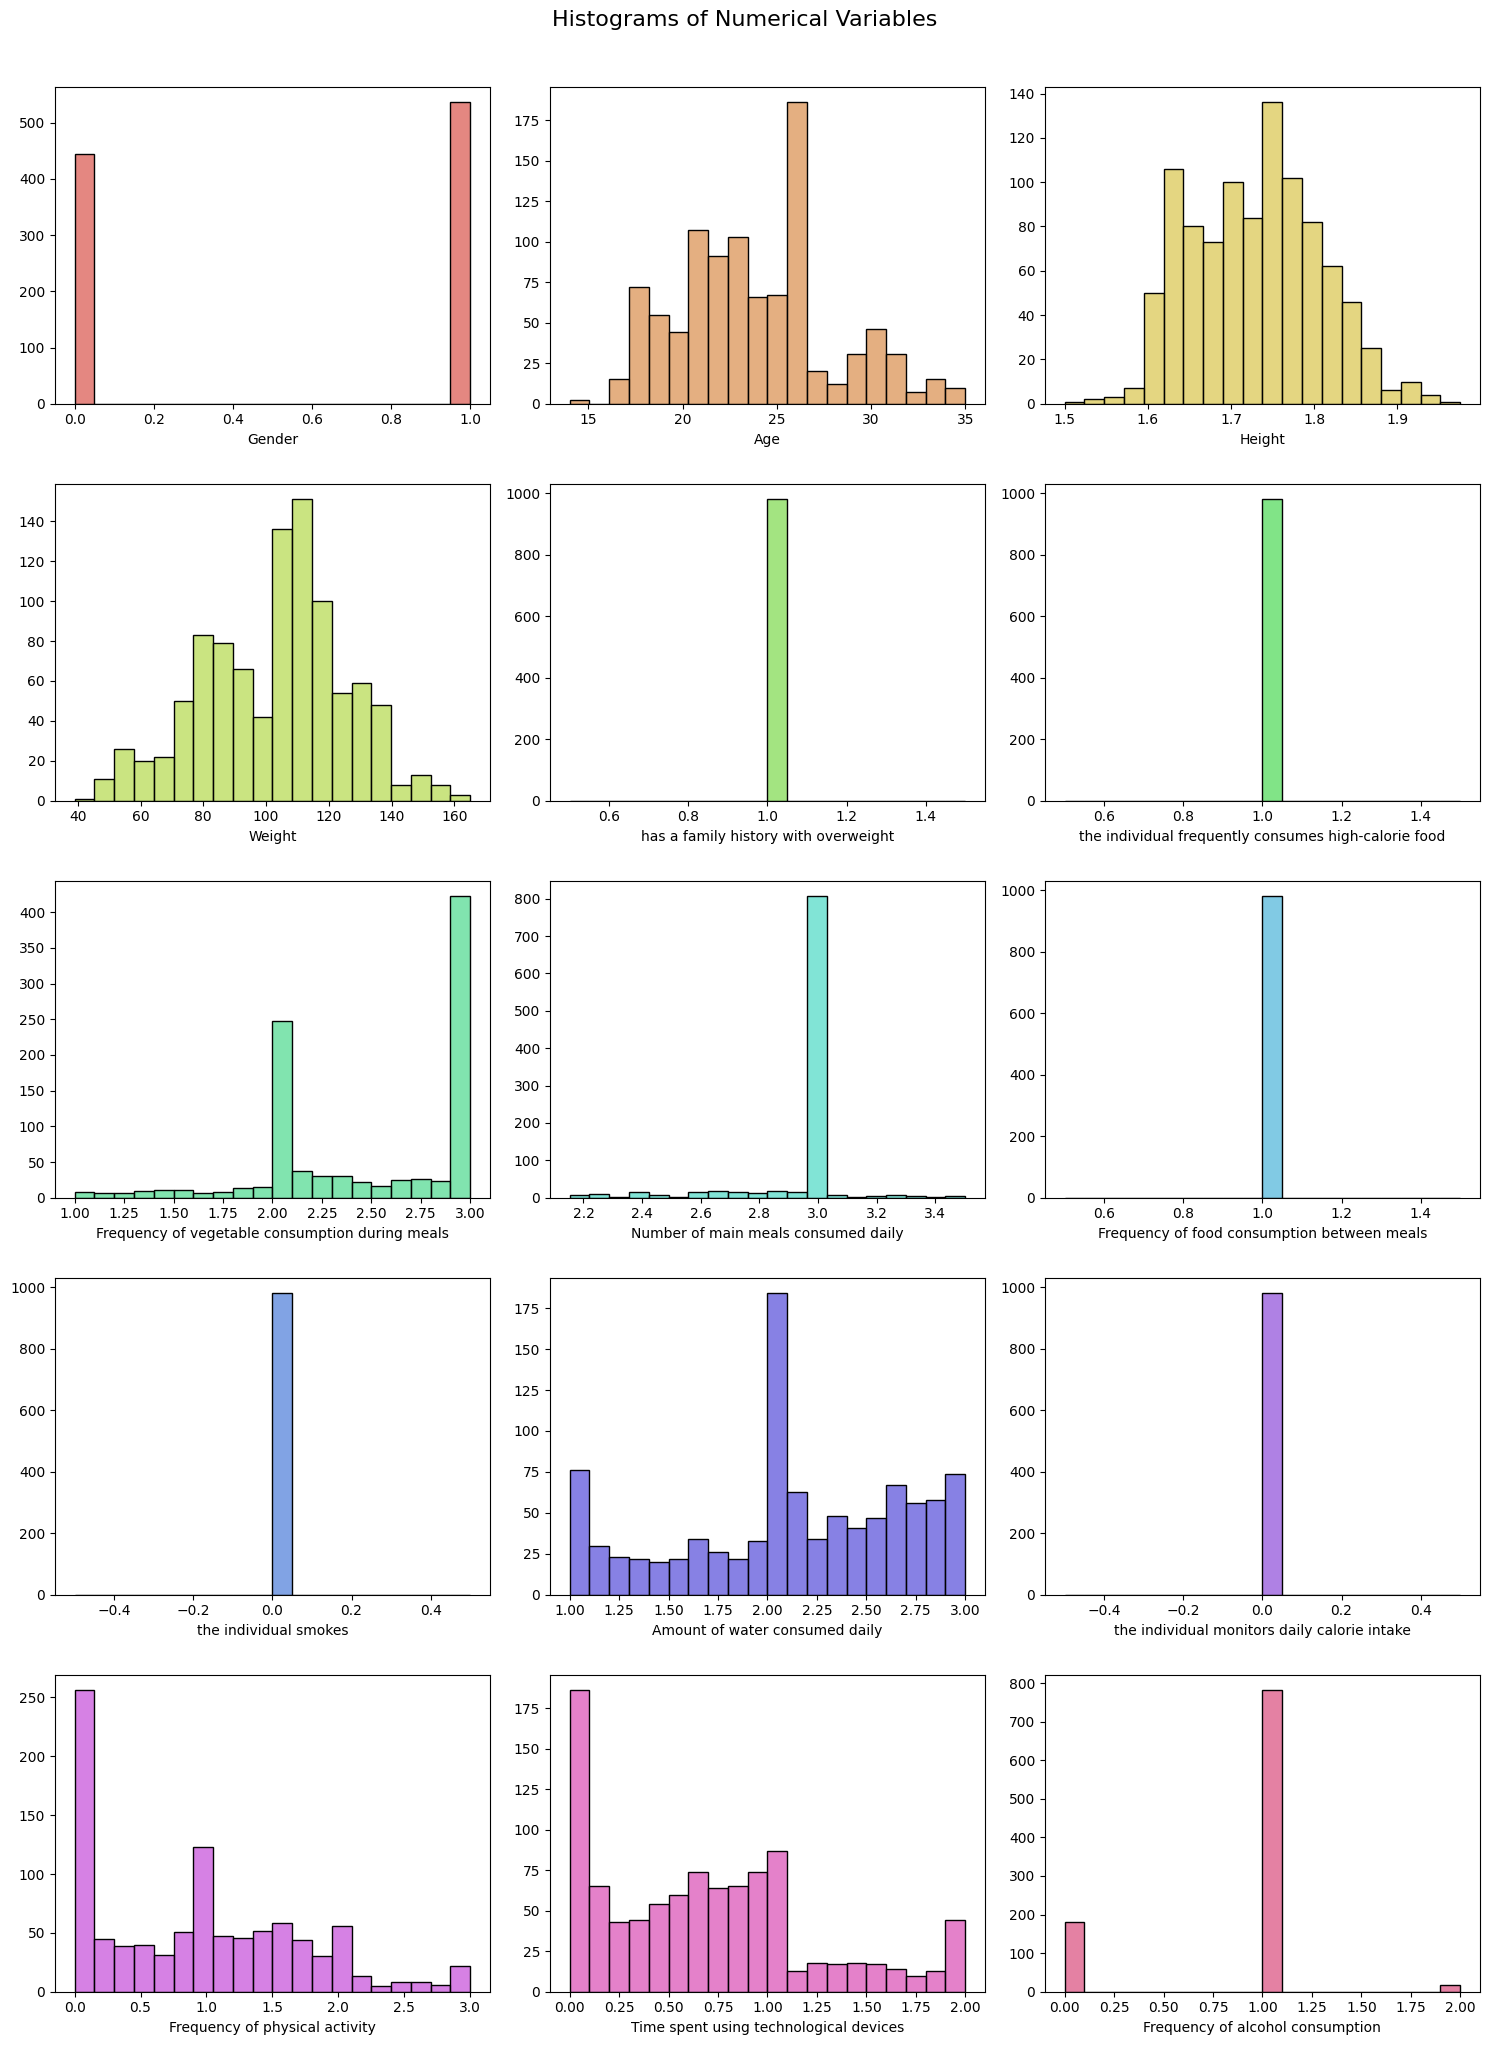

<Figure size 640x480 with 0 Axes>

In [24]:
numericColumnsPlot(dfOutliersRemoved, 3 )

These plots confirm skewness and kurtosis observations, and identify potential outliers understanding the shape of the data.

From these histograms, we can observe:

* Age, Height, Weight: These generally show distributions that are somewhat centered, but 'Age' and 'Weight' might exhibit some skewness or tails.
* Frequency of Consumption (FreVeg, NumMeals, WaterCons, FrePhyAc, TimeUseTech): Their distributions will show patterns related to how frequently these activities or consumptions occur in the dataset.
* Encoded Binary Variables (Gender, FamHist, FreHighCal, Smoke, MonitorDailyCal): As these are now 0s and 1s, their histograms will likely show two distinct bars, indicating the proportion of 'no' (0) and 'yes' (1) responses. Variables like 'Smoke' and 'MonitorDailyCal' with high skewness will show a very dominant bar for 'no' responses and a tiny bar for 'yes'.
* Encoded Ordinal Variables (FreBetweenMeals, FreAlcCons): These will display bars corresponding to their encoded values (0.0, 1.0, 2.0, 3.0), showing the frequency of each ordinal category. For 'FreAlcCons', you might notice the very low count for 'Always' (3.0), as identified during statistical exploration.
These visualizations confirm the statistical findings regarding the shape of the distributions, including observations about skewness and kurtosis.

In [25]:
# This cell previously attempted to remove outliers for 'Age' which caused a KeyError
# because dfOutliersRemoved was empty. Outlier removal for 'Age' and other numerical columns
# is now handled comprehensively in cell 'a1a11fbc' using the IQR method.

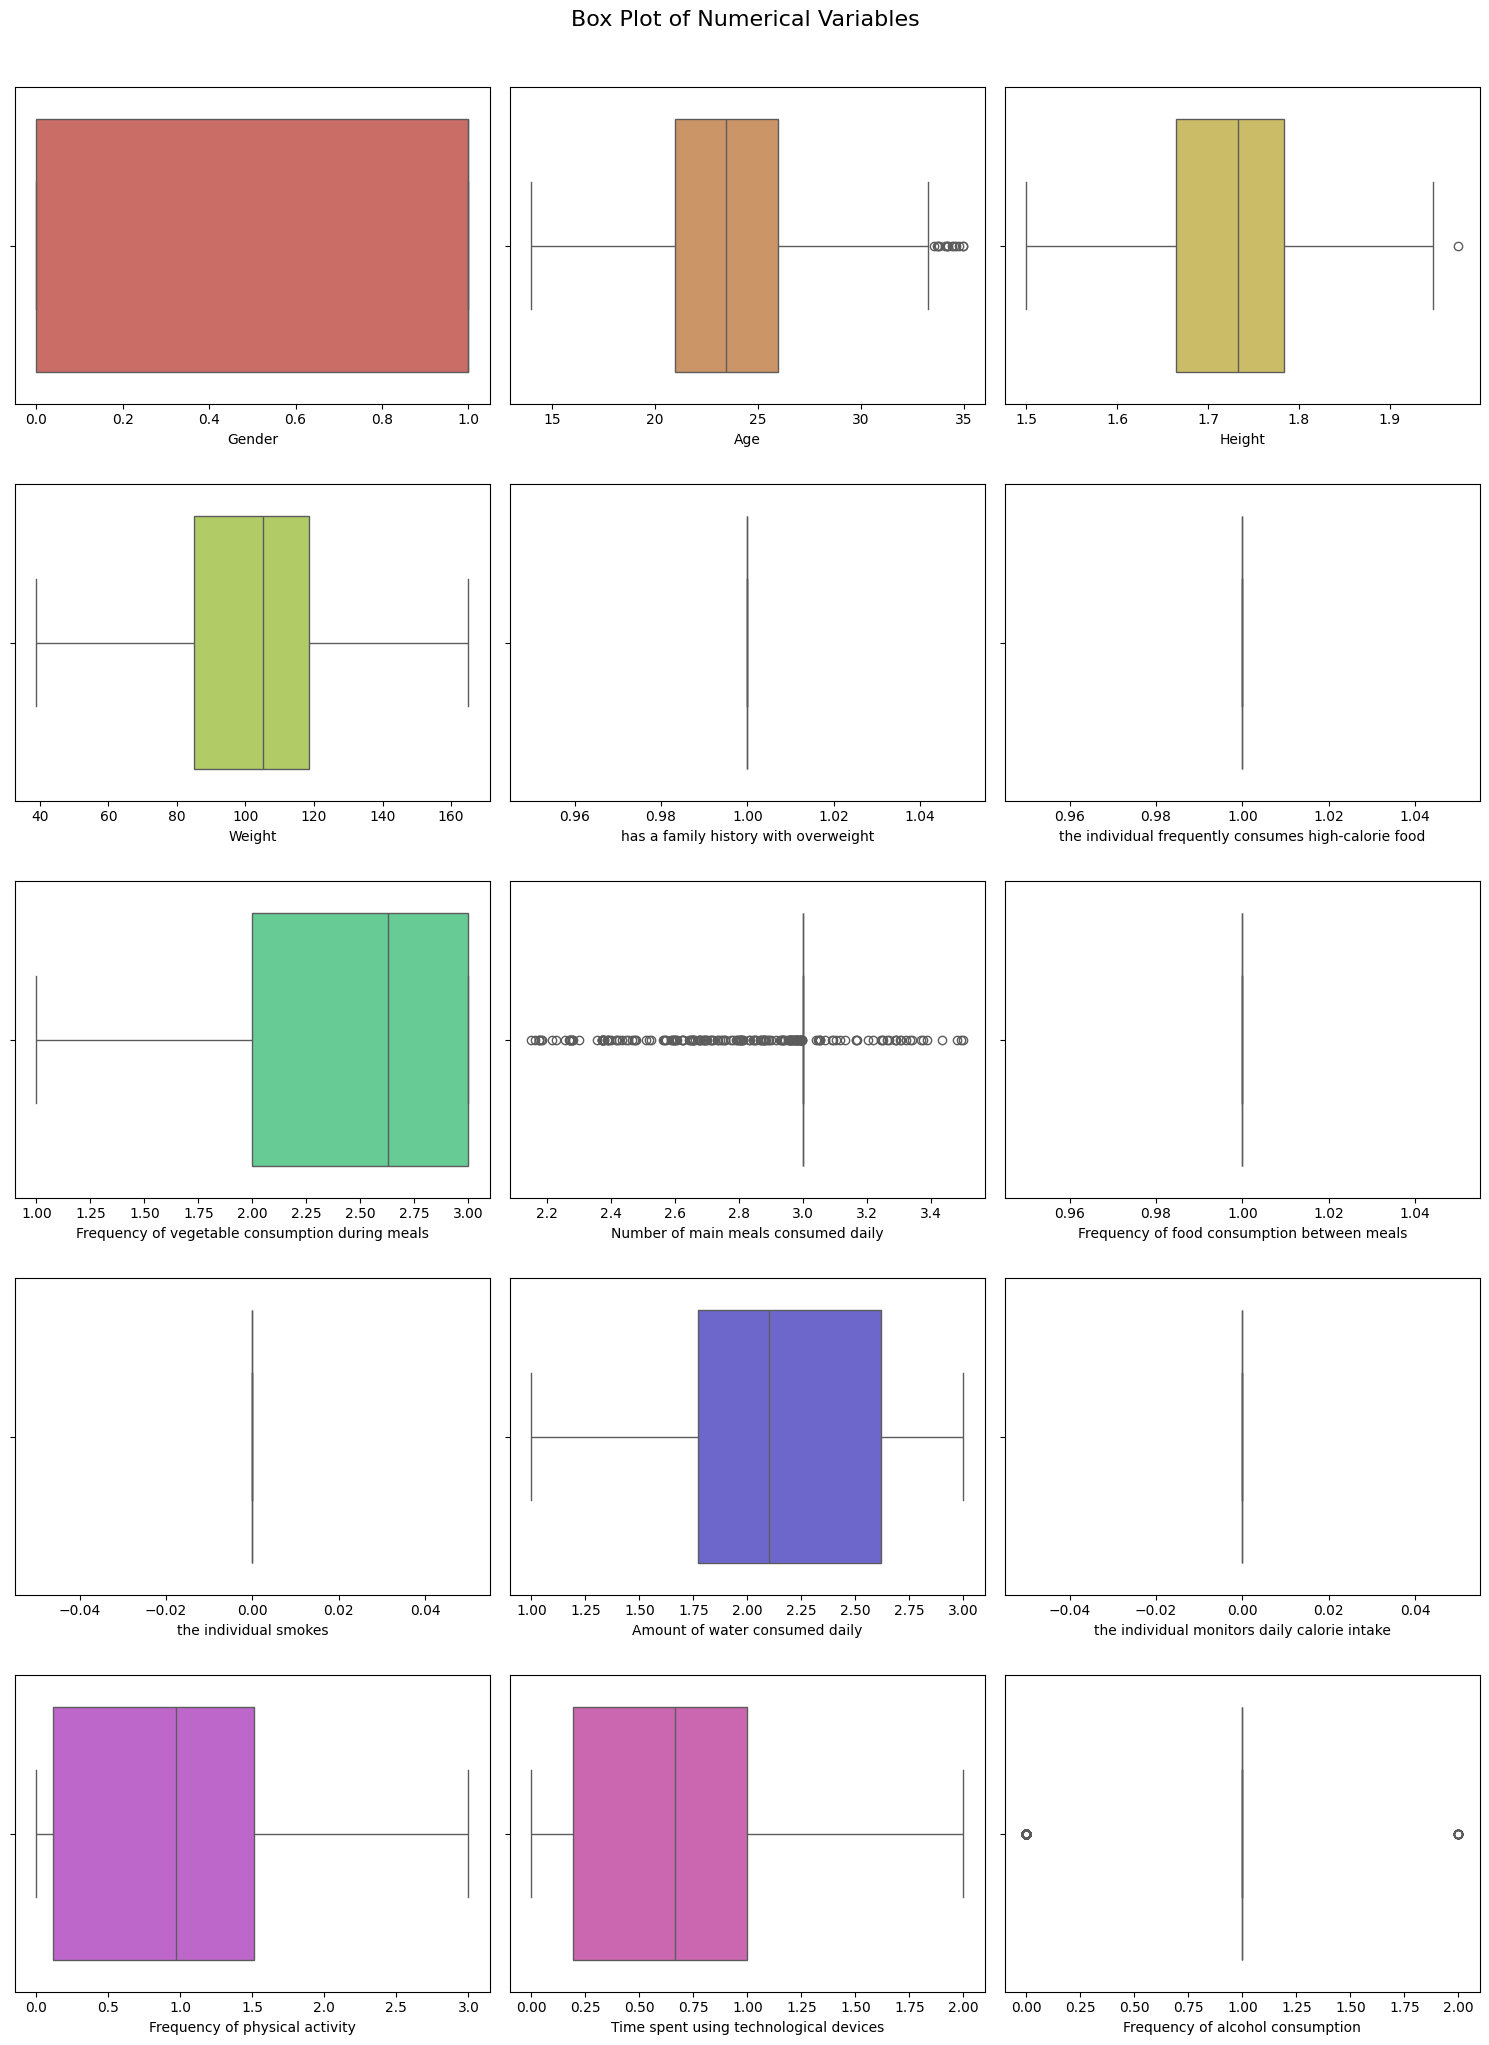

<Figure size 640x480 with 0 Axes>

In [26]:
numericColumnsPlot(dfOutliersRemoved, 3, BOX_PLOT)

The boxplots visualize the distribution of each numerical variable in the dfClean DataFrame, providing insights into their central tendency, spread, and potential outliers.

Each boxplot shows:

The box represents the interquartile range (IQR), from the first quartile (Q1, 25th percentile) to the third quartile (Q3, 75th percentile). The length of the box indicates the spread of the middle 50% of the data.
The line inside the box is the median (Q2, 50th percentile).
The 'whiskers' extend from the box to the minimum and maximum values within 1.5 times the IQR from Q1 and Q3, respectively.
Points beyond the whiskers are considered outliers.
From these boxplots, you can observe:

* **Age, Height, Weight**: You can visually identify the median, the spread of the middle 50% of the data, and explicitly see the individual data points that are considered outliers based on the 1.5 * IQR rule. This aligns with the numerical outlier detection we performed earlier.
* **Frequency of Consumption (FreVeg, NumMeals, WaterCons, FrePhyAc, TimeUseTech)**: These plots show the range of values and where the bulk of the data lies, along with any infrequent or extreme values. For example, NumMeals previously showed high negative skewness, which might manifest as the median being closer to the upper quartile and potential outliers on the lower end.
* **Encoded Binary Variables (Gender, FamHist, FreHighCal, Smoke, MonitorDailyCal)**: For these variables (now 0s and 1s), the boxplots will be very compressed, showing the median at 0 or 1 depending on the dominant category, and potentially the less frequent category appearing as outliers.
* **Encoded Ordinal Variables (FreBetweenMeals, FreAlcCons)**: The boxplots will show the distribution across the encoded numerical values (0.0, 1.0, 2.0, 3.0). For 'FreAlcCons', the single 'Always' value (3.0) will likely appear as an outlier, as noted in the statistical exploration.

- Column 'FreBetweenMeals': 344 outliers detected.
- Column 'Age': 168 outliers detected.
- Column 'MonitorDailyCal': 96 outliers detected.
- Column 'NumMeals': 579 outliers detected.
- Column 'Height': 1 outliers detected.

  - Column 'Weight': 0 outliers detected.
  - Column 'FreAlcCons': 0 outliers detected.
  - Column 'FreVeg': 0 outliers detected.
  - Column 'WaterCons': 0 outliers detected.
  - Column 'FrePhyAc': 0 outliers detected.
  - Column 'TimeUseTech': 0 outliers detected.

In [27]:
import numpy as np

dfCurrent = dfOutliersRemoved.copy()
InitialRows = len(dfCurrent)

# Columns to re-check for outliers and potentially remove
# ColsToCheck = ['FreBetweenMeals', 'Height', 'Weight','FreAlcCons','Age','MonitorDailyCal','FreVeg', 'NumMeals', 'WaterCons', 'FrePhyAc', 'TimeUseTech']
ColsToCheck = ['Height']

RowsToDrop = set()

print("Identifying and collecting outlier rows for removal:")
for Col in ColsToCheck:
    Q1 = dfCurrent[Col].quantile(0.25)
    Q3 = dfCurrent[Col].quantile(0.75)
    IQR = Q3 - Q1

    LowerBound = Q1 - 1.5 * IQR
    UpperBound = Q3 + 1.5 * IQR

    # Find indices of outliers
    OutlierIndices = dfCurrent[(dfCurrent[Col] < LowerBound) | (dfCurrent[Col] > UpperBound)].index
    RowsToDrop.update(OutlierIndices)
    print(f"  - Column '{Col}': {len(OutlierIndices)} outliers detected.")

print(f"\nTotal unique rows to drop based on selected columns: {len(RowsToDrop)}")

# Drop the identified rows
dfOutliersRemoved = dfCurrent.drop(index=list(RowsToDrop))

print(f"Original rows in dfOutliersRemoved: {InitialRows}")
print(f"Rows after removing selected outliers: {len(dfOutliersRemoved)}")

# Display info of the new DataFrame
dfOutliersRemoved.info()

Identifying and collecting outlier rows for removal:
  - Column 'Height': 1 outliers detected.

Total unique rows to drop based on selected columns: 1
Original rows in dfOutliersRemoved: 980
Rows after removing selected outliers: 979
<class 'pandas.core.frame.DataFrame'>
Index: 979 entries, 6 to 2110
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           979 non-null    int64  
 1   Age              979 non-null    float64
 2   Height           979 non-null    float64
 3   Weight           979 non-null    float64
 4   FamHist          979 non-null    int64  
 5   FreHighCal       979 non-null    int64  
 6   FreVeg           979 non-null    float64
 7   NumMeals         979 non-null    float64
 8   FreBetweenMeals  979 non-null    float64
 9   Smoke            979 non-null    int64  
 10  WaterCons        979 non-null    float64
 11  MonitorDailyCal  979 non-null    int64  
 12  FrePhyAc        

<div class="alert alert-block alert-info">
    
<a id='new'></a>

### 3.3 Create new variables
    
</div>
Create new variables in order to get variables with higher predictive power.

In [28]:
dfTransformed =dfOutliersRemoved.copy()
dfTransformed['Weight_Height'] =  dfOutliersRemoved['Weight'] / dfOutliersRemoved['Height']
dfTransformed['Age_Height'] = dfOutliersRemoved['Age'] / dfOutliersRemoved['Height']
dfTransformed['Age_Weight'] = dfOutliersRemoved['Age'] / dfOutliersRemoved['Weight']
display(dfTransformed)

,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBetweenMeals,Smoke,WaterCons,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,MTransp,TargetObesityL,Weight_Height,Age_Height,Age_Weight
6,0,23.000000,1.500000,55.000000,1,1,3.0,3.0,1.0,0,2.000000,0,1.000000,0.000000,1.0,Motorbike,Normal_Weight,36.666667,15.333333,0.418182
8,1,24.000000,1.780000,64.000000,1,1,3.0,3.0,1.0,0,2.000000,0,1.000000,1.000000,2.0,Public_Transportation,Normal_Weight,35.955056,13.483146,0.375000
9,1,22.000000,1.720000,68.000000,1,1,2.0,3.0,1.0,0,2.000000,0,1.000000,1.000000,0.0,Public_Transportation,Normal_Weight,39.534884,12.790698,0.323529
22,0,22.000000,1.650000,60.000000,1,1,3.0,3.0,1.0,0,2.000000,0,1.000000,0.000000,1.0,Automobile,Normal_Weight,36.363636,13.333333,0.366667
24,1,21.000000,1.850000,68.000000,1,1,2.0,3.0,1.0,0,2.000000,0,0.000000,1.000000,1.0,Public_Transportation,Normal_Weight,36.756757,11.351351,0.308824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,0,20.976842,1.710730,131.408528,1,1,3.0,3.0,1.0,0,1.728139,0,1.676269,0.906247,1.0,Public_Transportation,Obesity_Type_III,76.814300,12.261924,0.159631
2107,0,21.982942,1.748584,133.742943,1,1,3.0,3.0,1.0,0,2.005130,0,1.341390,0.599270,1.0,Public_Transportation,Obesity_Type_III,76.486427,12.571854,0.164367
2108,0,22.524036,1.752206,133.689352,1,1,3.0,3.0,1.0,0,2.054193,0,1.414209,0.646288,1.0,Public_Transportation,Obesity_Type_III,76.297737,12.854673,0.168480
2109,0,24.361936,1.739450,133.346641,1,1,3.0,3.0,1.0,0,2.852339,0,1.139107,0.586035,1.0,Public_Transportation,Obesity_Type_III,76.660232,14.005540,0.182696


<div class="alert alert-block alert-info">
    
<a id='scale'></a>

### 3.4. Scaling
    
</div>

In [29]:
from sklearn.preprocessing import StandardScaler

dfScaled = dfClean.copy()

# Identify numerical columns for scaling (excluding the encoded target variable)
NumericalCols = dfScaled.select_dtypes(include=['float64', 'int64']).columns.tolist()
NumericalCols.remove('TargetObesityL') # Exclude the target variable from scaling

# Initialize the StandardScaler
Scaler = StandardScaler()

# Apply scaling to the numerical columns
dfScaled[NumericalCols] = Scaler.fit_transform(dfScaled[NumericalCols])

print("\nDataFrame after feature scaling:")
display(dfScaled.head())


DataFrame after feature scaling:


,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBetweenMeals,Smoke,...,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,TargetObesityL,MTransp_Automobile,MTransp_Bike,MTransp_Motorbike,MTransp_Public_Transportation,MTransp_Walking
0,-1.011914,-0.522124,-0.875589,-0.862558,0.472291,-2.759769,-0.785019,0.404153,-0.300346,-0.145900,...,-0.218272,-1.188039,0.561997,-1.419172,1.0,-0.525642,-0.05768,-0.072375,0.579721,-0.165078
1,-1.011914,-0.522124,-1.947599,-1.168077,0.472291,-2.759769,1.088342,0.404153,-0.300346,6.853997,...,4.581439,2.339750,-1.080625,0.521160,1.0,-0.525642,-0.05768,-0.072375,0.579721,-0.165078
2,0.988227,-0.206889,1.054029,-0.366090,0.472291,-2.759769,-0.785019,0.404153,-0.300346,-0.145900,...,-0.218272,1.163820,0.561997,2.461491,1.0,-0.525642,-0.05768,-0.072375,0.579721,-0.165078
3,0.988227,0.423582,1.054029,0.015808,-2.117337,-2.759769,1.088342,0.404153,-0.300346,-0.145900,...,-0.218272,1.163820,-1.080625,2.461491,2.0,-0.525642,-0.05768,-0.072375,-1.724969,6.057758
4,0.988227,-0.364507,0.839627,0.122740,-2.117337,-2.759769,-0.785019,-2.167023,-0.300346,-0.145900,...,-0.218272,-1.188039,-1.080625,0.521160,3.0,-0.525642,-0.05768,-0.072375,0.579721,-0.165078


In [30]:
dfCat.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'FamHist', 'FreHighCal', 'FreVeg',
       'NumMeals', 'FreBetweenMeals', 'Smoke', 'WaterCons', 'MonitorDailyCal',
       'FrePhyAc', 'TimeUseTech', 'FreAlcCons', 'MTransp', 'TargetObesityL'],
      dtype='object')

</div>
<div class="alert alert-block alert-success">
<a id='depth'>
<font color = '#006400'>
    
#4. In-depth Exploration  </font>
</a>

    
[BACK TO TOC](#toc)    
</div>



In [31]:
# List of all Datasets after Preprocessing

print("df.head() Original Dataset with Variables renamed:")
display(df.head())
print("\ndfCat.head() Changed only binary variables, maintainde categorical:")
display(dfCat.head())
print("\ndfOrdinalEnc.head() Only ordinal encoding, MTrans still categorical:")
display(dfOrdinalEnc.head())
print("\ndfTargetEnc.head() Target encoding,, MTrans still categorical :")
display(dfTargetEnc.head())
print("\ndfClean.head(), MTrans one-hot encoding:")
display(dfClean.head())

# Outliers and other Transf
print("\ndfOutliersRemoved.head() Is not necessary to remove them all:")
display(dfOutliersRemoved.head())
print("\ndfTransformed.head():")
display(dfTransformed.head())
print("\ndfScaled.head():")
display(dfScaled.head())

df.head() Original Dataset with Variables renamed:


,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBetweenMeals,Smoke,WaterCons,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,MTransp,TargetObesityL
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



dfCat.head() Changed only binary variables, maintainde categorical:


,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBetweenMeals,Smoke,WaterCons,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,MTransp,TargetObesityL
0,0,21.0,1.62,64.0,1,0,2.0,3.0,Sometimes,0,2.0,0,0.0,1.0,no,Public_Transportation,Normal_Weight
1,0,21.0,1.52,56.0,1,0,3.0,3.0,Sometimes,1,3.0,1,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,1,23.0,1.80,77.0,1,0,2.0,3.0,Sometimes,0,2.0,0,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,1,27.0,1.80,87.0,0,0,3.0,3.0,Sometimes,0,2.0,0,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,1,22.0,1.78,89.8,0,0,2.0,1.0,Sometimes,0,2.0,0,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



dfOrdinalEnc.head() Only ordinal encoding, MTrans still categorical:


...

,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBetweenMeals,Smoke,WaterCons,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,MTransp,TargetObesityL
6,0,23.0,1.50,55.0,1,1,3.0,3.0,1.0,0,2.0,0,1.0,0.0,1.0,Motorbike,Normal_Weight
8,1,24.0,1.78,64.0,1,1,3.0,3.0,1.0,0,2.0,0,1.0,1.0,2.0,Public_Transportation,Normal_Weight
9,1,22.0,1.72,68.0,1,1,2.0,3.0,1.0,0,2.0,0,1.0,1.0,0.0,Public_Transportation,Normal_Weight
22,0,22.0,1.65,60.0,1,1,3.0,3.0,1.0,0,2.0,0,1.0,0.0,1.0,Automobile,Normal_Weight
24,1,21.0,1.85,68.0,1,1,2.0,3.0,1.0,0,2.0,0,0.0,1.0,1.0,Public_Transportation,Normal_Weight



dfTransformed.head():


,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBetweenMeals,Smoke,WaterCons,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,MTransp,TargetObesityL,Weight_Height,Age_Height,Age_Weight
6,0,23.0,1.50,55.0,1,1,3.0,3.0,1.0,0,2.0,0,1.0,0.0,1.0,Motorbike,Normal_Weight,36.666667,15.333333,0.418182
8,1,24.0,1.78,64.0,1,1,3.0,3.0,1.0,0,2.0,0,1.0,1.0,2.0,Public_Transportation,Normal_Weight,35.955056,13.483146,0.375000
9,1,22.0,1.72,68.0,1,1,2.0,3.0,1.0,0,2.0,0,1.0,1.0,0.0,Public_Transportation,Normal_Weight,39.534884,12.790698,0.323529
22,0,22.0,1.65,60.0,1,1,3.0,3.0,1.0,0,2.0,0,1.0,0.0,1.0,Automobile,Normal_Weight,36.363636,13.333333,0.366667
24,1,21.0,1.85,68.0,1,1,2.0,3.0,1.0,0,2.0,0,0.0,1.0,1.0,Public_Transportation,Normal_Weight,36.756757,11.351351,0.308824



dfScaled.head():


,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBetweenMeals,Smoke,...,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,TargetObesityL,MTransp_Automobile,MTransp_Bike,MTransp_Motorbike,MTransp_Public_Transportation,MTransp_Walking
0,-1.011914,-0.522124,-0.875589,-0.862558,0.472291,-2.759769,-0.785019,0.404153,-0.300346,-0.145900,...,-0.218272,-1.188039,0.561997,-1.419172,1.0,-0.525642,-0.05768,-0.072375,0.579721,-0.165078
1,-1.011914,-0.522124,-1.947599,-1.168077,0.472291,-2.759769,1.088342,0.404153,-0.300346,6.853997,...,4.581439,2.339750,-1.080625,0.521160,1.0,-0.525642,-0.05768,-0.072375,0.579721,-0.165078
2,0.988227,-0.206889,1.054029,-0.366090,0.472291,-2.759769,-0.785019,0.404153,-0.300346,-0.145900,...,-0.218272,1.163820,0.561997,2.461491,1.0,-0.525642,-0.05768,-0.072375,0.579721,-0.165078
3,0.988227,0.423582,1.054029,0.015808,-2.117337,-2.759769,1.088342,0.404153,-0.300346,-0.145900,...,-0.218272,1.163820,-1.080625,2.461491,2.0,-0.525642,-0.05768,-0.072375,-1.724969,6.057758
4,0.988227,-0.364507,0.839627,0.122740,-2.117337,-2.759769,-0.785019,-2.167023,-0.300346,-0.145900,...,-0.218272,-1.188039,-1.080625,0.521160,3.0,-0.525642,-0.05768,-0.072375,0.579721,-0.165078


In [81]:
# 4. Create a DataFrame to make it easy to read
ObesityLabels = [
    'Insufficient_Weight (0)', 'Normal_Weight (1)', 'Overweight_I (2)',
    'Overweight_II (3)', 'Obesity_I (4)', 'Obesity_II (5)', 'Obesity_III (6)'
]


<div class="alert alert-block alert-info">
    
<a id='inDepht_1'></a>

### 4.1. Do physical activity levels significantly influence obesity classification?
    
</div>


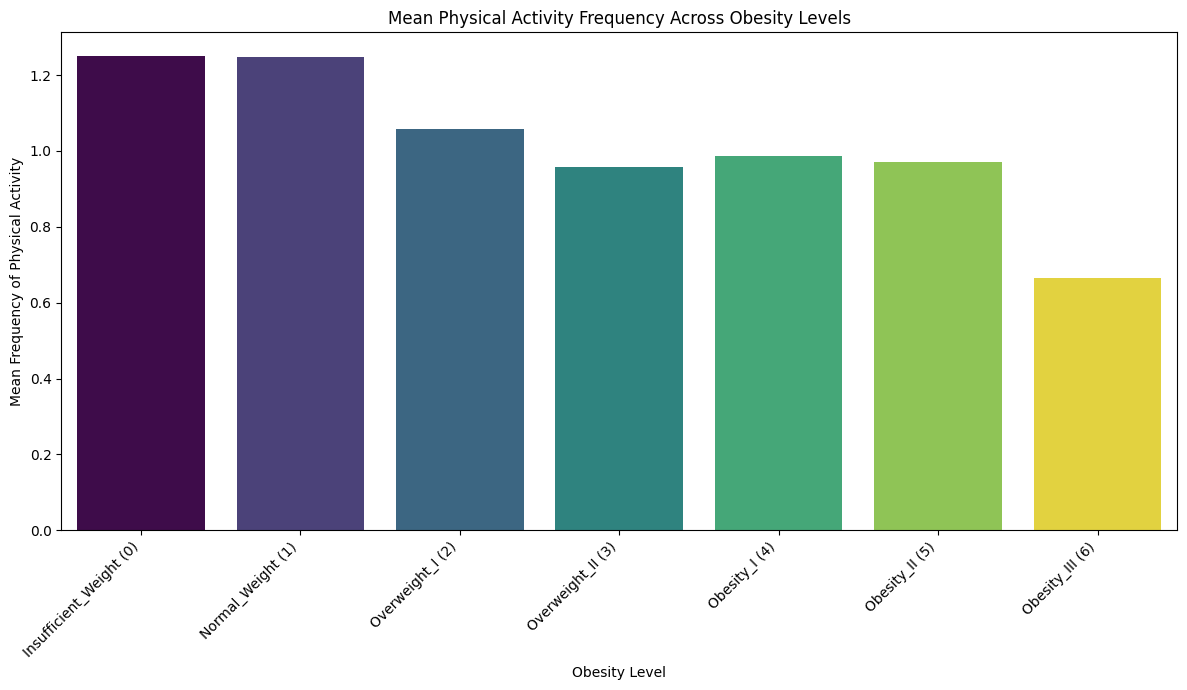

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the mean physical activity frequency for each Obesity Level
mean_phy_ac_by_obesity = dfClean.groupby('TargetObesityL')['FrePhyAc'].mean().reset_index()

# Define numerical order for the x-axis
obesity_numeric_order = sorted(dfClean['TargetObesityL'].unique())

plt.figure(figsize=(12, 7))
sns.barplot(x='TargetObesityL', y='FrePhyAc', data=mean_phy_ac_by_obesity, order=obesity_numeric_order, palette='viridis', hue='TargetObesityL', legend=False)
plt.title('Mean Physical Activity Frequency Across Obesity Levels')
plt.xlabel('Obesity Level')
plt.ylabel('Mean Frequency of Physical Activity')
# Use ObesityLabels for readable tick labels
plt.xticks(ticks=range(len(ObesityLabels)), labels=ObesityLabels, rotation=45, ha='right')
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
    
<a id='inDepht_2'></a>

### 4.2. Are eating habits stronger predictors of obesity than demographic factors?
    
</div>



In [54]:
dfOrdinalEnc.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'FamHist', 'FreHighCal', 'FreVeg',
       'NumMeals', 'FreBetweenMeals', 'Smoke', 'WaterCons', 'MonitorDailyCal',
       'FrePhyAc', 'TimeUseTech', 'FreAlcCons', 'MTransp', 'TargetObesityL'],
      dtype='object')

To determine whether eating habits are stronger predictors of obesity than demographic factors, we can refer to the feature importance results from the Random Forest and Tuned Gradient Boosting models, along with the coefficient analysis from Logistic Regression.

### **Insights from Random Forest (without 'Weight' feature)**
(Using `FeatureImportanceDfNl`)

*   **Top Individual Predictors:**
    *   `Age` (Demographic): 0.141877
    *   `FreVeg` (Eating Habit): 0.123820
    *   `NumMeals` (Eating Habit): 0.083827
    *   `WaterCons` (Eating Habit): 0.07734778
    *   `Gender` (Demographic): 0.05678053
    *   `FreBetweenMeals` (Eating Habit): 0.0504126
    *   `FreAlcCons` (Eating Habit): 0.0496179
    *   `FamHist` (Demographic): 0.04532674

*   **Summary:** 'Age' stands out as the single strongest predictor. However, several eating habits (`FreVeg`, `NumMeals`, `WaterCons`, `FreBetweenMeals`, `FreAlcCons`) follow closely, and collectively, the eating habits features show a substantial combined importance.

### **Insights from Tuned Gradient Boosting Model**
(Using `feature_importance_df_gb`)

*   **Top Individual Predictors:**
    *   `Age` (Demographic): 0.172327
    *   `FreVeg` (Eating Habit): 0.163572
    *   `NumMeals` (Eating Habit): 0.079754
    *   `Gender` (Demographic): 0.075494
    *   `FreBetweenMeals` (Eating Habit): 0.070364
    *   `WaterCons` (Eating Habit): 0.064590
    *   `FamHist` (Demographic): 0.055374
    *   `FreAlcCons` (Eating Habit): 0.044812

*   **Summary:** Similar to the Random Forest, 'Age' is the strongest predictor, with `FreVeg` being a very close second. The set of eating habits collectively demonstrates significant predictive power, often outweighing demographic factors when considered as a group.

### **Insights from Logistic Regression (Coefficient Heatmap)**

The Logistic Regression heatmap for the model (without 'Weight' and 'Height') shows:

*   **Demographic Factors:**
    *   `Age`: Consistently shows positive coefficients for higher obesity levels (e.g., Obesity Type II and III), indicating that older age is associated with an increased likelihood of more severe obesity classifications.
    *   `FamHist`: Positive coefficients for higher obesity levels, suggesting a family history of overweight increases obesity risk.
    *   `Gender`: Has mixed effects, contributing differently across various obesity classifications.

*   **Eating Habits:**
    *   `FreVeg`: Shows strong negative coefficients for most obesity levels, indicating that frequent vegetable consumption decreases the likelihood of obesity. An interesting observation is its positive correlation with `Obesity_III`, which could indicate medical advice for these individuals.
    *   `FreHighCal`: Generally shows positive coefficients for higher obesity levels, meaning frequent consumption of high-calorie food increases obesity risk.
    *   `NumMeals`, `WaterCons`, `FreBetweenMeals`, `FreAlcCons`: Also exhibit varying coefficients, but often show a clear directional impact on obesity levels.

### **Conclusion**

While **Age** frequently appears as the single most important individual predictor across models, the collective influence of **eating habits** as a group (including `FreVeg`, `NumMeals`, `WaterCons`, `FreBetweenMeals`, `FreHighCal`, `FreAlcCons`) often demonstrates a stronger or comparable predictive power to demographic factors (`Gender`, `Age`, `FamHist`).

Specifically:

*   **`Age` (demographic) is consistently the strongest individual predictor.**
*   **`FreVeg` (eating habit) is a very strong individual predictor, often ranking second or very close to `Age`.**
*   When considering the **combined impact** of all listed eating habits versus all listed demographic factors, the eating habits collectively tend to be **stronger predictors** of obesity levels. Many eating habits show significant, independent contributions to predicting obesity outcomes.

<div class="alert alert-block alert-info">
    
<a id='inDepht_3'></a>

### 4.3. Is there a relationship between technology usage (screen time) and obesity levels?
    
</div>


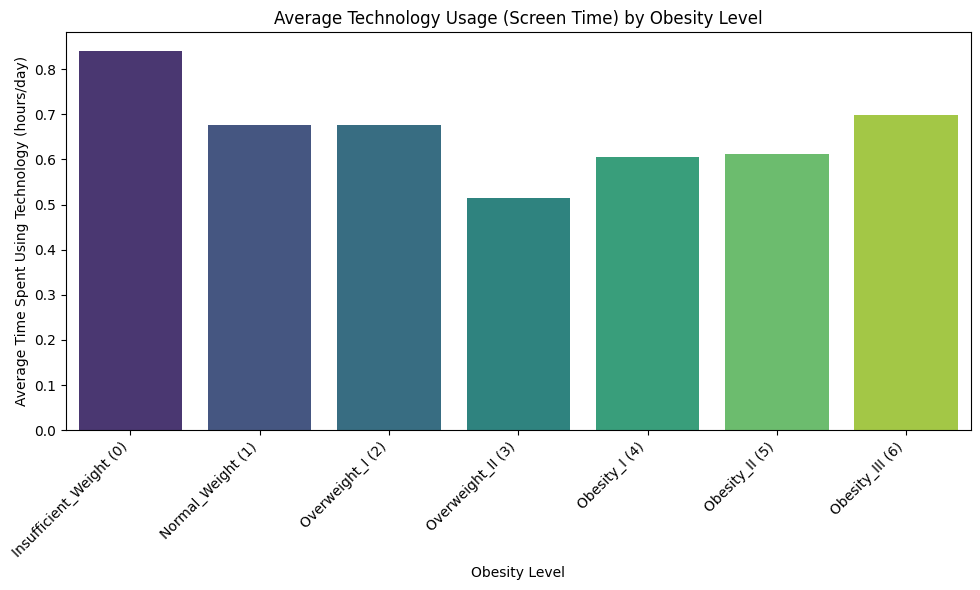

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate the mean TimeUseTech for each Obesity Level
mean_time_use_tech = dfOrdinalEnc.groupby('TargetObesityL')['TimeUseTech'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='TargetObesityL', y='TimeUseTech', data=mean_time_use_tech, palette='viridis', hue='TargetObesityL', legend=False)
plt.title('Average Technology Usage (Screen Time) by Obesity Level')
plt.xlabel('Obesity Level')
plt.ylabel('Average Time Spent Using Technology (hours/day)')
plt.xticks(ticks=range(len(ObesityLabels)), labels=ObesityLabels, rotation=45, ha='right')
plt.tight_layout()
plt.show()

The bar chart visualizes the average time spent using technology across different obesity levels.

From the chart, we can observe the following trends:

*   **Lower Obesity Levels (Insufficient_Weight, Normal_Weight):** These categories generally show lower average technology usage.
*   **Overweight Levels (Overweight_Level_I, Overweight_Level_II):** The average screen time seems to increase slightly in these categories compared to normal weight individuals.
*   **Obesity Types (Obesity_Type_I, Obesity_Type_II, Obesity_Type_III):** The average screen time tends to be higher for individuals in the obesity categories, with 'Obesity_Type_I' showing a noticeable peak in average time spent. Interestingly, 'Obesity_Type_II' and 'Obesity_Type_III' show slightly lower averages than 'Obesity_Type_I', but still higher than 'Insufficient_Weight' and 'Normal_Weight'.

Overall, there appears to be a general positive relationship: individuals in higher obesity classifications tend to report higher average technology usage, although the trend isn't strictly linear across all obesity types. This suggests that increased screen time might be a contributing factor or a correlated behavior with higher obesity levels.

<div class="alert alert-block alert-info">
    
<a id='inDepht_4'></a>

### 4.4. Do transportation habits correlate with healthier lifestyles?
    
</div>


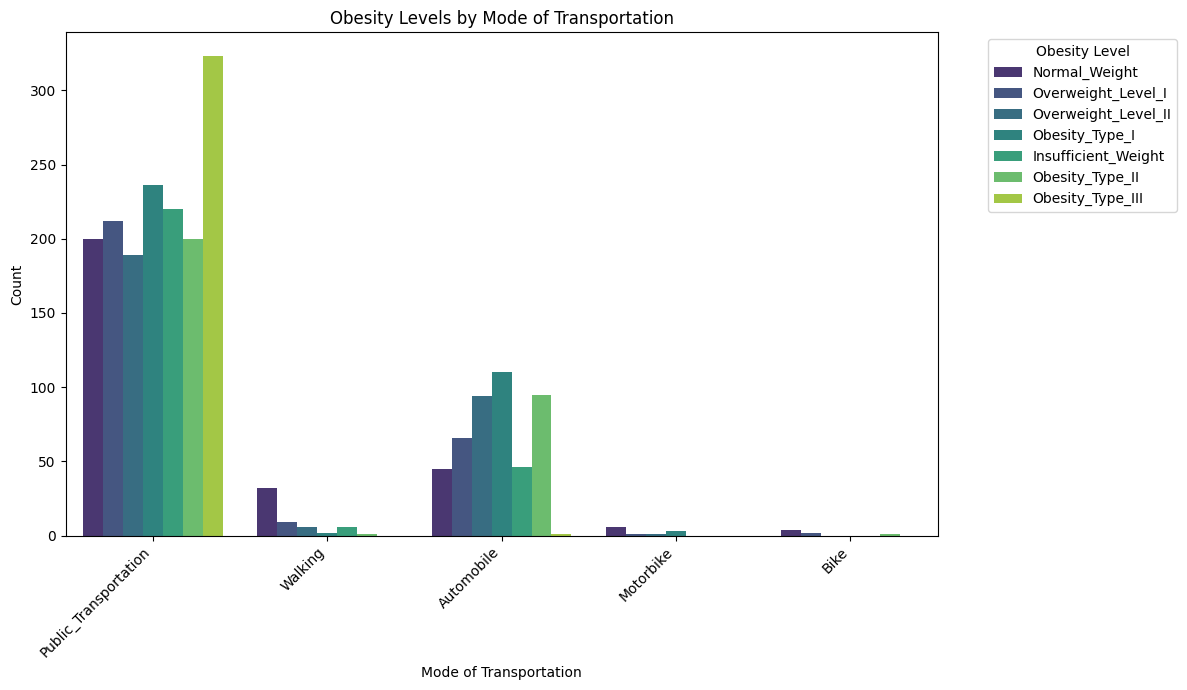

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.countplot(x='MTransp', hue='TargetObesityL', data=dfOrdinalEnc, palette='viridis')
plt.title('Obesity Levels by Mode of Transportation')
plt.xlabel('Mode of Transportation')
plt.ylabel('Count')
plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
    
<a id='inDepht_5'></a>

### 4.5. Can obesity patterns vary across age groups or genders?
    
</div>


In [90]:
# Define the order of the obesity levels for consistent plotting
ObesityOrder_Labels = [
    'Insufficient Weight',
    'Normal Weight',
    'Overweight Level_I',
    'Overweight Level_II',
    'Obesity Type_I',
    'Obesity Type_II',
    'Obesity Type_III'
]

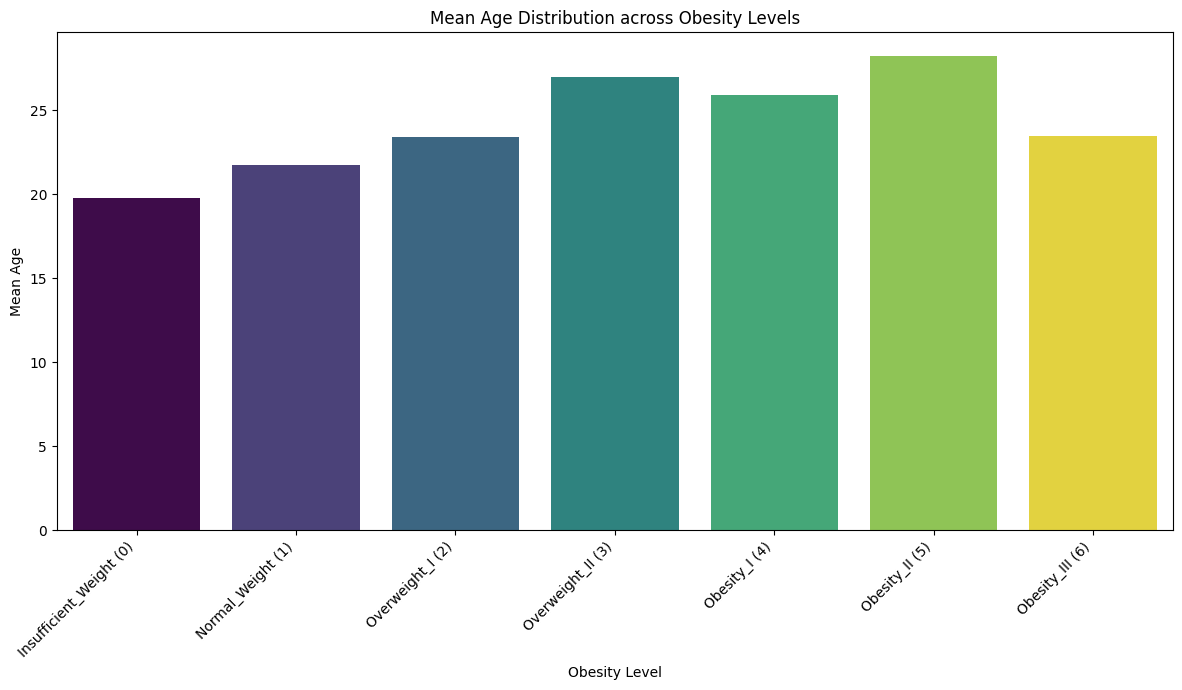

In [93]:
# mean age for each Obesity Level
mean_age_by_obesity = dfClean.groupby('TargetObesityL')['Age'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='TargetObesityL', y='Age', data=mean_age_by_obesity, order=obesity_numeric_order, palette='viridis', hue='TargetObesityL', legend=False)
plt.title('Mean Age Distribution across Obesity Levels')
plt.xlabel('Obesity Level')
plt.ylabel('Mean Age')
plt.xticks(ticks=range(len(ObesityLabels)), labels=ObesityLabels, rotation=45, ha='right')
plt.tight_layout()
plt.show()

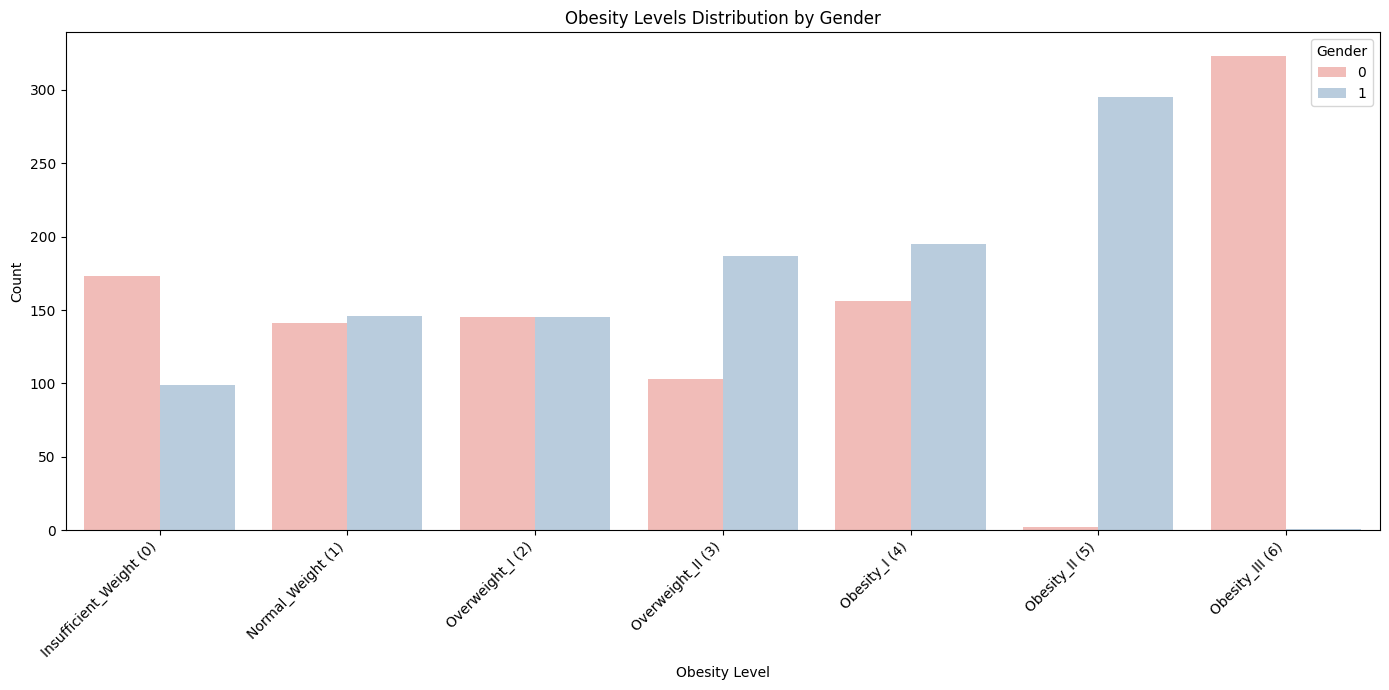

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

# Obesity Levels Distribution by Gender
plt.figure(figsize=(14, 7))
sns.countplot(x='TargetObesityL', hue='Gender', data=dfClean, order=obesity_numeric_order, palette='Pastel1')
plt.title('Obesity Levels Distribution by Gender')
plt.xlabel('Obesity Level')
plt.ylabel('Count')
plt.xticks(ticks=range(len(ObesityLabels)), labels=ObesityLabels, rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

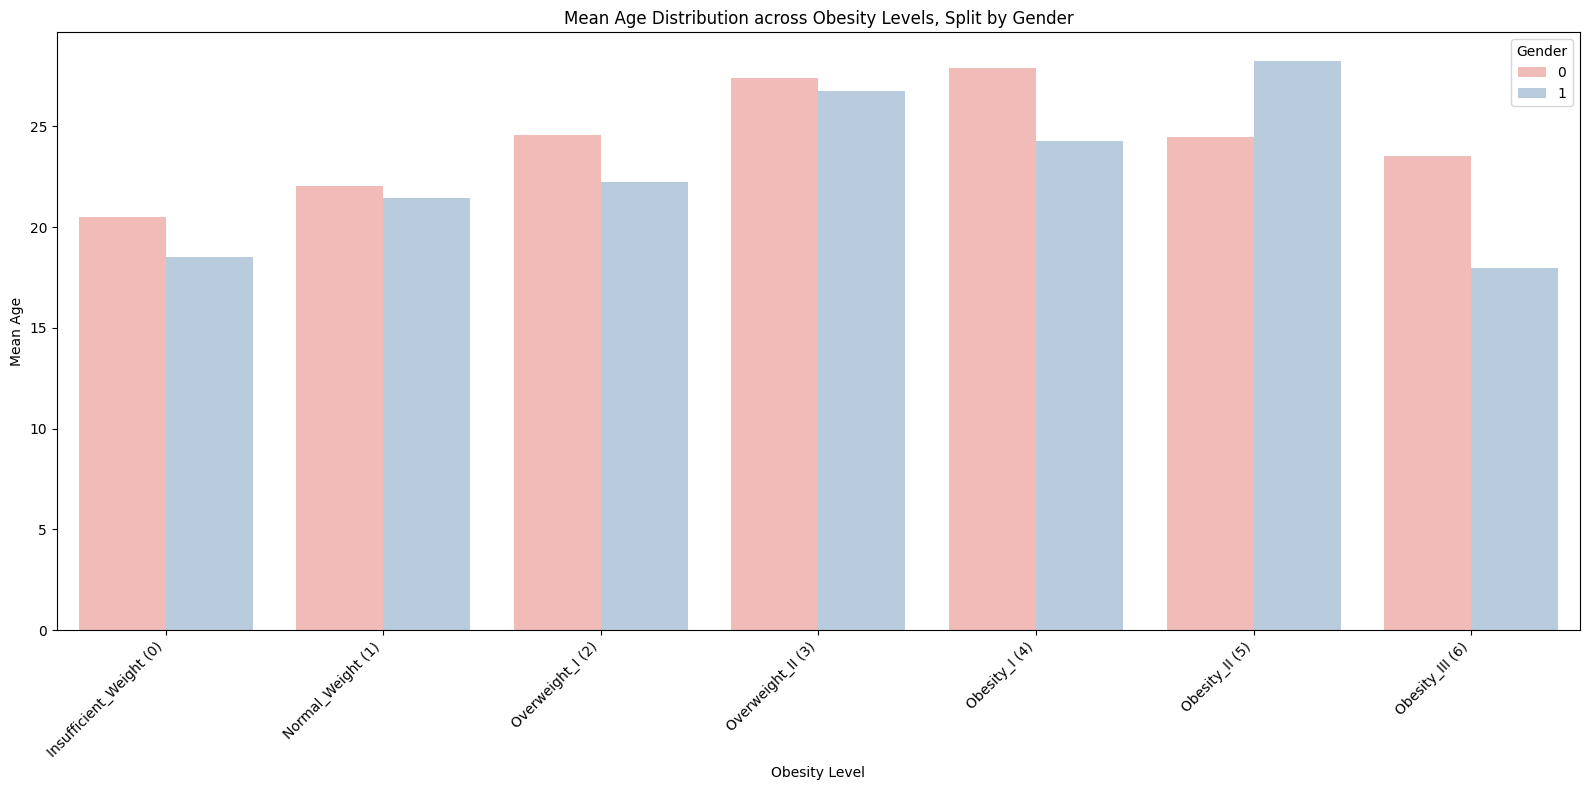

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the mean age for each Obesity Level, split by Gender
mean_age_by_obesity_gender = dfClean.groupby(['TargetObesityL', 'Gender'])['Age'].mean().reset_index()

plt.figure(figsize=(16, 8))
sns.barplot(x='TargetObesityL', y='Age', hue='Gender', data=mean_age_by_obesity_gender,
            order=obesity_numeric_order, palette='Pastel1')
plt.title('Mean Age Distribution across Obesity Levels, Split by Gender')
plt.xlabel('Obesity Level')
plt.ylabel('Mean Age')
plt.xticks(ticks=range(len(ObesityLabels)), labels=ObesityLabels, rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

The plot showing the 'Mean Age Distribution across Obesity Levels, Split by Gender' provides interesting insights into how age and gender interact with different obesity classifications:

*   **General Trend:** For both genders, there's a general trend of increasing mean age as obesity levels rise, particularly from 'Insufficient Weight' up to 'Obesity Type II'.
*   **Gender Differences in Lower Levels:** In the 'Insufficient Weight', 'Normal Weight', and 'Overweight Level I' categories, females generally have a slightly higher mean age than males.
*   **Gender Differences in Higher Levels:**
    *   For 'Obesity Type I' and 'Obesity Type III', females show a higher mean age compared to males within those categories.
    *   Conversely, for 'Obesity Type II', males have a higher mean age than females.
*   **Notable Observation:** The mean age for males in 'Obesity Type III' is notably lower than for females in the same category, and also lower than males in 'Obesity Type II'. This might suggest different underlying factors or demographic distributions within the most severe obesity classification, or it could be an anomaly worth further investigation.

These patterns suggest that age and gender play complex roles in obesity, with varying mean ages across different obesity levels and distinct distributions between males and females.

<div class="alert alert-block alert-success">
<a id='preprocess'>
<font color = '#006400'>
    
# 5. Predictive Modeling</font>
</a>

The plot shows the distribution of obesity levels across different modes of transportation.

We can observe that 'Public Transportation' is the most common mode, and it's associated with a wide range of obesity levels, with a notable presence of 'Obesity_Type_I', 'Obesity_Type_II', and 'Obesity_Type_III'.

'Automobile' usage also shows various obesity levels, but with a different distribution compared to public transport.

'Walking' appears to be associated with lower obesity levels, such as 'Normal_Weight' and

'Insufficient_Weight', though the counts are much smaller overall.


'Motorbike' and 'Bike' are used by very few individuals, making it difficult to draw strong conclusions about their association with obesity levels from this plot alone.


These findings suggest that transportation habits do correlate with obesity patterns, particularly with public transportation and walking.

<div class="alert alert-block alert-warning">

<a id='clean'></a>

## 5.1 Logistic Regression
    
</div>

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# 1. Start fresh from dfClean to guarantee no messy notebook memory
dfFinal = dfClean.copy()

# 2. Define EXACTLY which columns are continuous numbers
# Notice: No categorical/text columns are in this list!
ContinuousCols = ['Age', 'Height', 'Weight', 'FreVeg', 'NumMeals', 'WaterCons', 'FrePhyAc', 'TimeUseTech']

# 3. Scale only those continuous columns
Scaler = StandardScaler()
dfFinal[ContinuousCols] = Scaler.fit_transform(dfFinal[ContinuousCols])
dfFinal.info()

# 4. Separate Features (X) and Target (Y)
X = dfFinal.drop(columns=['TargetObesityL'])
Y = dfFinal['TargetObesityL']

# 5. Train/Test Split (80% training, 20% testing)
XTrain, XTest, YTrain, YTest = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# 6. Train Logistic Regression
# We set max_iter=2000 to ensure the math has enough time to converge
LogModel = LogisticRegression(max_iter=2000)
LogModel.fit(XTrain, YTrain)

# 7. Predict and Evaluate
YPred = LogModel.predict(XTest)

print("--- Logistic Regression Performance ---")
print(f"Accuracy:  {accuracy_score(YTest, YPred):.4f}")
print(f"Precision: {precision_score(YTest, YPred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(YTest, YPred, average='weighted'):.4f}")

print("\n--- Detailed Classification Report ---")
print(classification_report(YTest, YPred))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Gender                         2111 non-null   int64  
 1   Age                            2111 non-null   float64
 2   Height                         2111 non-null   float64
 3   Weight                         2111 non-null   float64
 4   FamHist                        2111 non-null   int64  
 5   FreHighCal                     2111 non-null   int64  
 6   FreVeg                         2111 non-null   float64
 7   NumMeals                       2111 non-null   float64
 8   FreBetweenMeals                2111 non-null   float64
 9   Smoke                          2111 non-null   int64  
 10  WaterCons                      2111 non-null   float64
 11  MonitorDailyCal                2111 non-null   int64  
 12  FrePhyAc                       2111 non-null   f

<div class="alert alert-block alert-warning">

<a id='clean'></a>

## 5.2 Random Forest to confirm the most important predictors
    
</div>

--- Random Forest Performance ---
Accuracy:  0.9433
Precision: 0.9479
Recall:    0.9433


/tmp/ipykernel_68029/833758374.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=FeatureImportanceDf, palette='viridis')


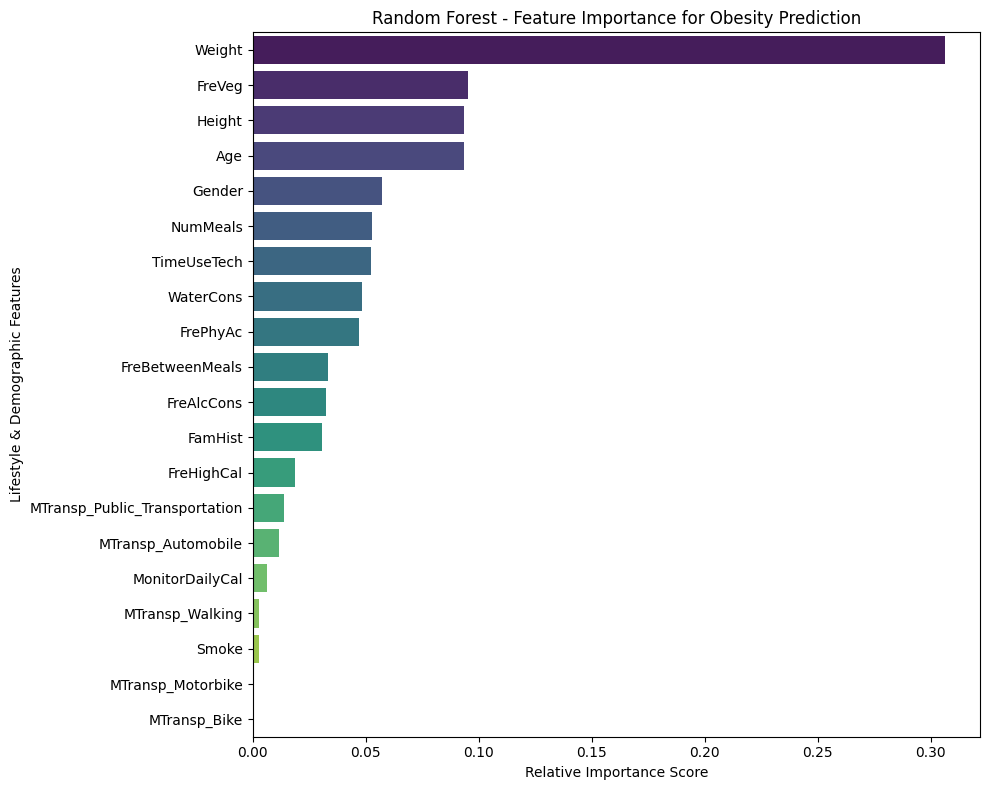

,Feature,Importance
3,Weight,0.306452
6,FreVeg,0.095362
2,Height,0.093686
1,Age,0.093437
0,Gender,0.057144
7,NumMeals,0.052946
13,TimeUseTech,0.052340
10,WaterCons,0.048249
12,FrePhyAc,0.046944
8,FreBetweenMeals,0.033528


In [40]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize and train the Random Forest model
# n_estimators=100 means we are building a "forest" of 100 decision trees
RfModel = RandomForestClassifier(n_estimators=100, random_state=42)
RfModel.fit(XTrain, YTrain)

# 2. Make predictions and evaluate performance
RfYPred = RfModel.predict(XTest)

print("--- Random Forest Performance ---")
print(f"Accuracy:  {accuracy_score(YTest, RfYPred):.4f}")
print(f"Precision: {precision_score(YTest, RfYPred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(YTest, RfYPred, average='weighted'):.4f}")

# 3. Extract Feature Importance to answer your Research Questions
Importances = RfModel.feature_importances_
FeatureNames = X.columns

FeatureImportanceDf = pd.DataFrame({
    'Feature': FeatureNames,
    'Importance': Importances
}).sort_values(by='Importance', ascending=False)

# 4. Plot the Feature Importances
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=FeatureImportanceDf, palette='viridis')
plt.title('Random Forest - Feature Importance for Obesity Prediction')
plt.xlabel('Relative Importance Score')
plt.ylabel('Lifestyle & Demographic Features')
plt.tight_layout()
plt.show()

# 5. Display the exact numerical values
display(FeatureImportanceDf)

--- Random Forest (Including Height, Without Weight) ---
Accuracy:  0.8747


/tmp/ipykernel_68029/2396026782.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=FeatureImportanceDfNl, palette='magma')


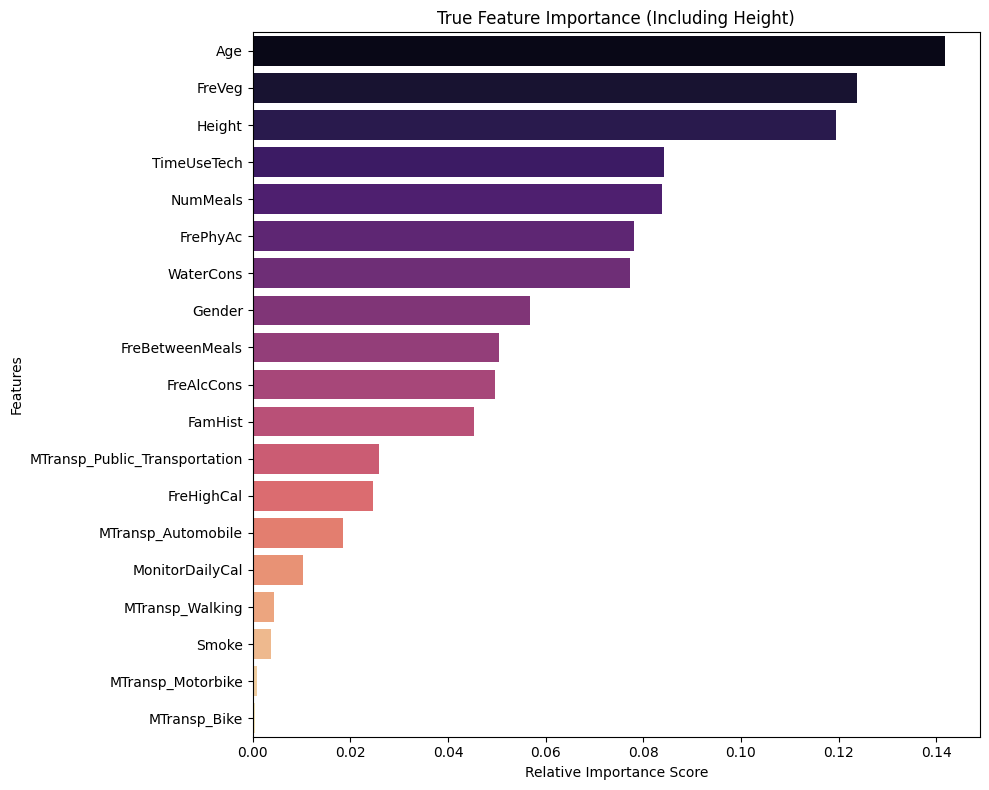

,Feature,Importance
1,Age,0.141877
5,FreVeg,0.123820
2,Height,0.119532
12,TimeUseTech,0.084273
6,NumMeals,0.083827
11,FrePhyAc,0.078178
9,WaterCons,0.077348
0,Gender,0.056781
7,FreBetweenMeals,0.050413
13,FreAlcCons,0.049618


In [41]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Separate Features (X) and Target (Y), but DROP ONLY Weight this time!
XNoLeakage = dfFinal.drop(columns=['TargetObesityL', 'Weight'])
YNoLeakage = dfFinal['TargetObesityL']

# 2. Train/Test Split
XTrainNl, XTestNl, YTrainNl, YTestNl = train_test_split(
    XNoLeakage, YNoLeakage, test_size=0.2, random_state=42, stratify=YNoLeakage
)

# 3. Train the Random Forest
RfModelNl = RandomForestClassifier(n_estimators=100, random_state=42)
RfModelNl.fit(XTrainNl, YTrainNl)

# 4. Predict and Evaluate
RfYPredNl = RfModelNl.predict(XTestNl)

print("--- Random Forest (Including Height, Without Weight) ---")
print(f"Accuracy:  {accuracy_score(YTestNl, RfYPredNl):.4f}")

# 5. Extract and Plot the REAL Feature Importance
ImportancesNl = RfModelNl.feature_importances_
FeatureNamesNl = XNoLeakage.columns

FeatureImportanceDfNl = pd.DataFrame({
    'Feature': FeatureNamesNl,
    'Importance': ImportancesNl
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=FeatureImportanceDfNl, palette='magma')
plt.title('True Feature Importance (Including Height)')
plt.xlabel('Relative Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Print the exact numerical values
display(FeatureImportanceDfNl)

--- Logistic Regression: Direction of Relationships ---
Positive numbers (Red) = Increases likelihood of this category
Negative numbers (Blue) = Decreases likelihood of this category



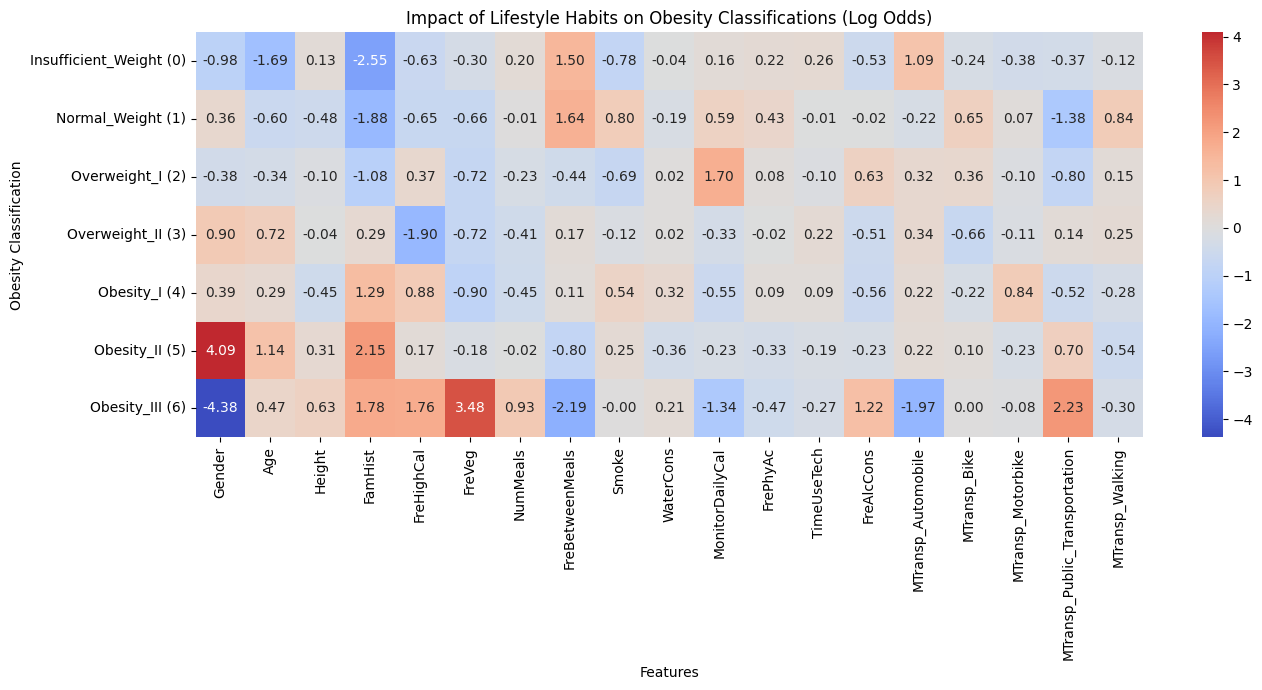

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# 1. Retrain Logistic Regression on the SAME data used for Feature Importance (XTrainNl)
# This ensures the number of coefficients (columns) matches the feature names.
LogModelNl = LogisticRegression(max_iter=2000)
LogModelNl.fit(XTrainNl, YTrainNl)

# 2. Get the names of the features we used
FeatureNames = XTrainNl.columns

# 3. Extract the coefficients from the NEWLY trained model
Coefficients = LogModelNl.coef_

# 4. Create a DataFrame to make it easy to read
ObesityLabels = [
    'Insufficient_Weight (0)', 'Normal_Weight (1)', 'Overweight_I (2)',
    'Overweight_II (3)', 'Obesity_I (4)', 'Obesity_II (5)', 'Obesity_III (6)'
]

# Now Coefficients and FeatureNames both have a length of 18
CoefDf = pd.DataFrame(Coefficients, columns=FeatureNames, index=ObesityLabels)

# 5. Display the table with a color map
print("--- Logistic Regression: Direction of Relationships ---")
print("Positive numbers (Red) = Increases likelihood of this category")
print("Negative numbers (Blue) = Decreases likelihood of this category\n")

plt.figure(figsize=(14, 7))
sns.heatmap(CoefDf, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Impact of Lifestyle Habits on Obesity Classifications (Log Odds)')
plt.ylabel('Obesity Classification')
plt.xlabel('Features')
plt.tight_layout()
plt.show()

Q1: Frequent physical activity is a moderately strong predictor, but not a key predictor.

Q2: When looking at the top predictors of obesity in the random forest analysis, the demographic variables "Age" and "Height" are notably stronger predictors than other lifestyle variables, with the exception of frequent consumption of vegetables. The logistic regression chart shows that the risk of higher obesity levels increase with age. Taller people are also at increased risk of higher levels of obesity. Frequent consumption of vegetables interestingly decreases the likelihood of all categories with the exception of the highest level of obesity, which has an extremely strong relationship with it. This could potentially be due to these individuals being medically perscribed a vegetable-rich diet in order to maintain health.

<div class="alert alert-block alert-warning">

<a id='clean'></a>

## 5.3 Decision Trees - IN PROGRESS (Annamaria)
    
</div>

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Start fresh from dfClean to guarantee no messy notebook memory
dfTrees = dfClean.copy()

# 2. Prevent Target Leakage
X = dfTrees.drop(columns=['TargetObesityL', 'Weight', 'Height'])
y = dfTrees['TargetObesityL']

# 3. Handle Categorical Variables (already handled in previous steps, so get_dummies is not needed here)
# All relevant columns in X are already numerical due to prior encoding or are inherently numerical.

# 4. Train/Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Initialize and Train the Decision Tree
# We set a random_state for reproducibility
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

# 6. Generate Predictions
y_pred = tree_model.predict(X_test)

# Print Accuracy separately
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

# Print Precision, Recall, and F1-Score for all 7 classes
print("Detailed Performance Metrics:")
print(classification_report(y_test, y_pred))

Overall Accuracy: 75.41%

Detailed Performance Metrics:
              precision    recall  f1-score   support

         0.0       0.76      0.86      0.81        56
         1.0       0.64      0.68      0.66        62
         2.0       0.64      0.61      0.62        56
         3.0       0.56      0.58      0.57        50
         4.0       0.83      0.64      0.72        78
         5.0       0.84      0.91      0.88        58
         6.0       0.95      1.00      0.98        63

    accuracy                           0.75       423
   macro avg       0.75      0.75      0.75       423
weighted avg       0.76      0.75      0.75       423



How to interpret the report:

Accuracy: The percentage of total patients whose obesity level was guessed correctly.

Precision (by class): Out of all the people the tree labeled as "Obesity Type II," how many actually were?

Recall (by class): Out of all the people who truly are "Obesity Type II," how many did the tree successfully find?

Macro Avg vs. Weighted Avg: Look at the "macro avg" at the bottom of the report to see the average precision and recall across all 7 classes, treating each class equally regardless of how many synthetic samples it has.

Below we can visualize the tree structure that will provide immediate feedback on the most important behavioral features in predicting obesity.

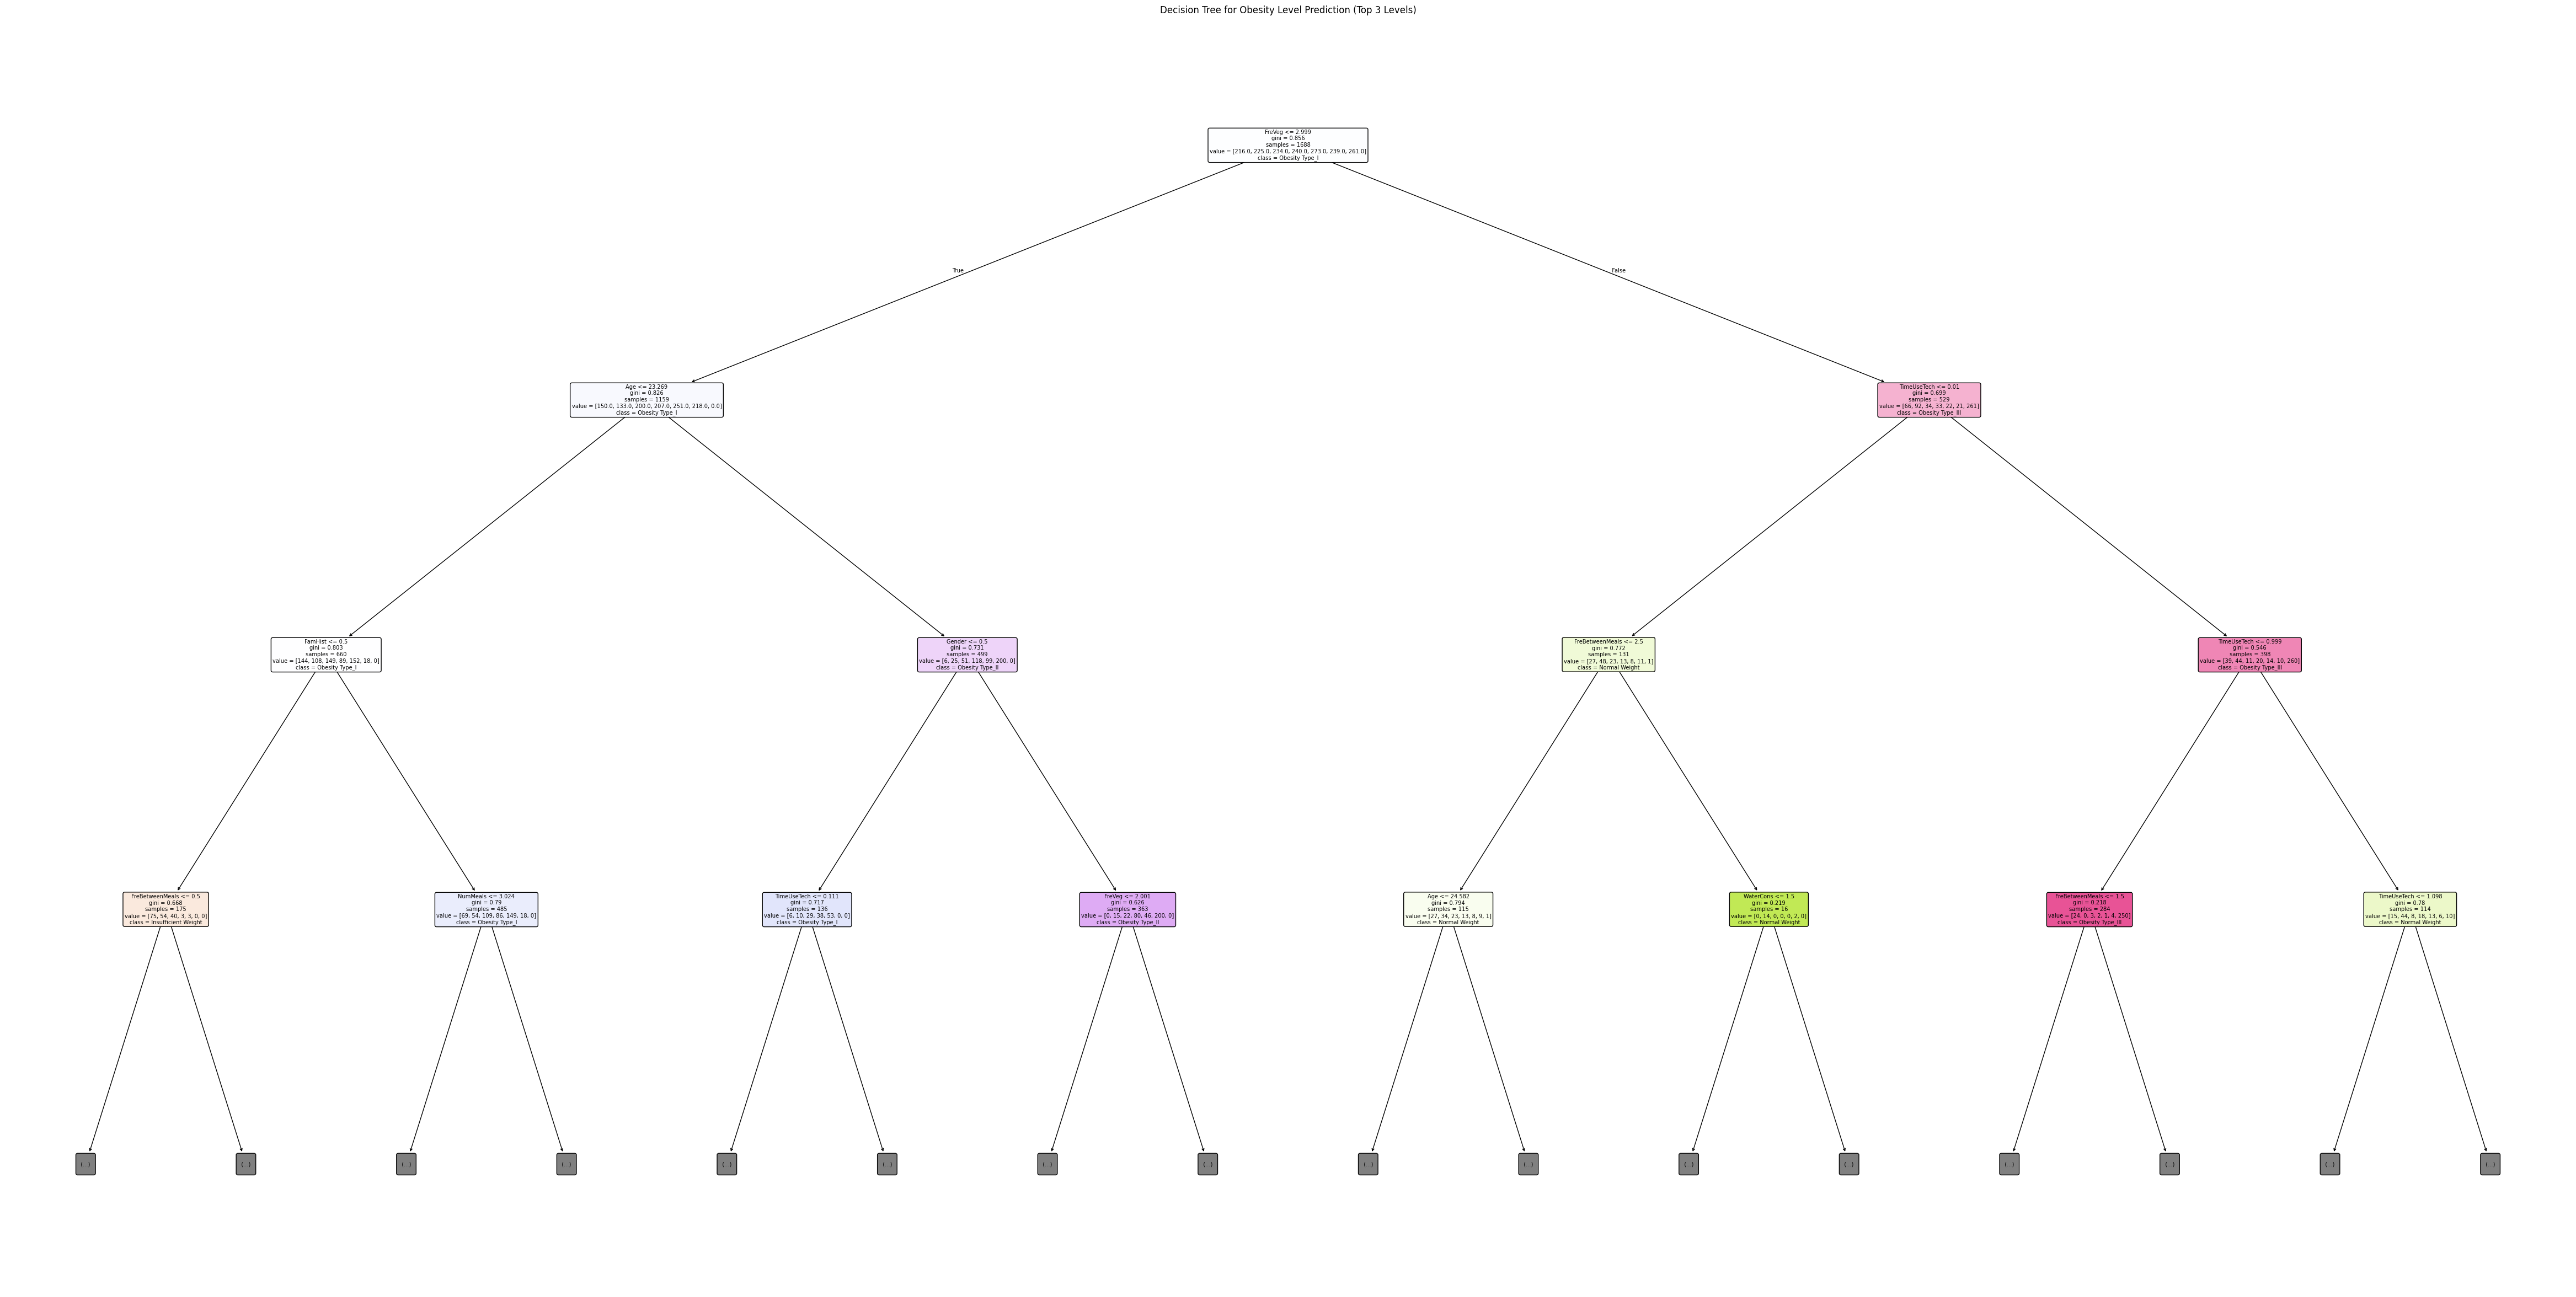

In [44]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(60, 30))
# We limit max_depth to 3 just for visualization purposes,
# otherwise the plot becomes too crowded to read.
plot_tree(tree_model,
          feature_names=X.columns,
          class_names=[ObesityLabels[int(c)] for c in tree_model.classes_],
          filled=True,
          rounded=True,
          max_depth=3)

plt.title("Decision Tree for Obesity Level Prediction (Top 3 Levels)")
plt.show()

<div class="alert alert-block alert-warning">
    
<a id='clean'></a>

## 5.4 Support Vector Machine (SVM) model
    
</div>

The Support Vector Machine (SVM) model in order to work for our target class, the predictor for obesity, needs to be adapted as it is not a  binary class but a multiclass value. We can utilize the SVM model applying the multiclass One-Vs-Rest approach that generally provides a better result over the One-Vs-One approach. The One-Vs-Rest algorithm creates a one binary classifier for each of the 7 classes in the Obesity target dataset, it will train 7 separate SVMs. For the predition the data of a new patient it will be evaliated across all 7 models. The model that output the outputs the highest confidence score (the largest distance from the margin) "wins," and that class is chosen.
The phyton Scikit package is handling all the mathematical complexity simplfifying the algorithm usage.


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# 1. Start fresh from dfClean to guarantee no messy notebook memory
# Drop Weight and Height to prevent target leakage
dfSVN = dfClean.copy()

# Define EXACTLY which columns are continuous numbers
# Gender, FamHist, FreHighCal, Smoke, MonitorDailyCal, FreBetweenMeals, FreAlcCons are already numerical (int/float).
# MTransp is now one-hot encoded.
# Exclude TargetObesityL, Weight, and Height for X as per the problem description
ContinuousCols = [
    'Age', 'FreVeg', 'NumMeals', 'WaterCons', 'FrePhyAc', 'TimeUseTech',
    'Gender', 'FamHist', 'FreHighCal', 'Smoke', 'MonitorDailyCal',
    'FreBetweenMeals', 'FreAlcCons'
]

# Filter ContinuousCols to exclude 'Weight' and 'Height' as per the cell's initial comment
ContinuousCols_for_scaling = [col for col in ContinuousCols if col not in ['Weight', 'Height']]

# Scale only those continuous columns
scaler = StandardScaler()
dfSVN[ContinuousCols_for_scaling] = scaler.fit_transform(dfSVN[ContinuousCols_for_scaling])

# Separate Features (X) and Target (Y)
X = dfSVN.drop(columns=['TargetObesityL', 'Weight', 'Height']) # Drop Weight and Height as per comment
y = dfSVN['TargetObesityL']

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the SVM Model
# scikit-learn uses One-vs-Rest ('ovr') by default.
# You can change it to One-vs-One by setting decision_function_shape='ovo'
svm_model = SVC(kernel='rbf', decision_function_shape='ovr', C=1.0)

# 4. Train and Evaluate
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.76      0.86      0.81        56
         1.0       0.60      0.58      0.59        62
         2.0       0.68      0.61      0.64        56
         3.0       0.64      0.50      0.56        50
         4.0       0.72      0.69      0.71        78
         5.0       0.76      0.93      0.84        58
         6.0       0.97      1.00      0.98        63

    accuracy                           0.74       423
   macro avg       0.73      0.74      0.73       423
weighted avg       0.74      0.74      0.74       423



Visualization of the relevance of a variable by analizing how badly the model break when shuffling the values for the patience through the Permutation Importance method. If it change drammatically it means tha the variable was relevant, if the changes are minimal it means tha the variable was of minor importance for the predictive model.

Calculating feature relevance...


/tmp/ipykernel_68029/3108758298.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


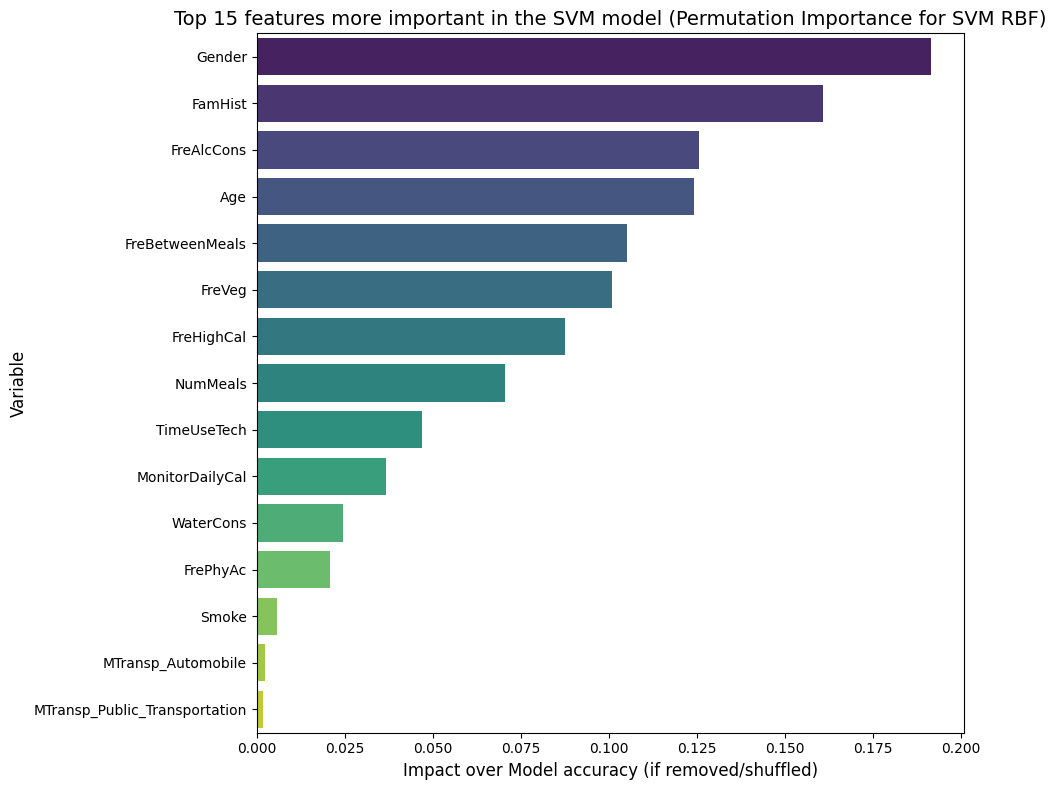

In [46]:
from sklearn.inspection import permutation_importance
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the Permutation Importance of the Test Set
# (n_repeats=10 means that it is shuffling 10 times the data to be sure about the result obtained)
print("Calculating feature relevance...")
result_relevance = permutation_importance(
    svm_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# 2. Create a FataFramce to collect and reorder the results
# Using X.columns as ti contains the names of the variables after the pd.get_dummies()
df_importance = pd.DataFrame({
    'Variable': X.columns,
    'Importance_Medium': result_relevance.importances_mean,
    'Deviation_Standard': result_relevance.importances_std
})

# 3. Ordering the variables from the more important to the less important
# Considering only the top 15 for clarity of the plot
df_top15 = df_importance.sort_values(by='Importance_Medium', ascending=False).head(15)

# 4. Generating the plot
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance_Medium',
    y='Variable',
    data=df_top15,
    palette='viridis' # Intuitive palette
)

# Beautifying the plot
plt.title("Top 15 features more important in the SVM model (Permutation Importance for SVM RBF)", fontsize=14)
plt.xlabel("Impact over Model accuracy (if removed/shuffled)", fontsize=12)
plt.ylabel("Variable", fontsize=12)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">
    
<a id='clean'></a>

## 5.5 K-Nearest Neighbors
    
</div>

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# 1. Start fresh from dfClean
dfKNN = dfClean.copy()

# Define the numerical columns for scaling, excluding the target and features to drop
# Ensure all MTransp one-hot encoded columns are included
NumericalColsForScaling = [
    'Gender', 'Age', 'FreVeg', 'NumMeals', 'FreBetweenMeals', 'Smoke',
    'WaterCons', 'MonitorDailyCal', 'FrePhyAc', 'TimeUseTech', 'FreAlcCons',
    'FamHist', 'FreHighCal',
    'MTransp_Automobile', 'MTransp_Bike', 'MTransp_Motorbike', 'MTransp_Public_Transportation', 'MTransp_Walking'
]

# Filter out 'Weight' and 'Height' if they were intended to be in NumericalColsForScaling but should be dropped from X
# For dfClean, 'Weight' and 'Height' are separate columns, not within the existing one-hot encoded 'MTransp' context
# So, directly exclude them from scaling if they are to be dropped from X later

# Instantiate StandardScaler
scaler = StandardScaler()

# Scale the identified numerical features in dfKNN
dfKNN[NumericalColsForScaling] = scaler.fit_transform(dfKNN[NumericalColsForScaling])

# 2. Separate Features (X) and Target (y)
# Drop 'Weight' and 'Height' from features to prevent target leakage, along with the target itself
X = dfKNN.drop(columns=['TargetObesityL', 'Weight', 'Height'])
y = dfKNN['TargetObesityL']

# 3. Train/Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Initialize and Train the K-Nearest Neighbors model
# Using n_neighbors=5 as a common starting point
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# 5. Generate Predictions
y_pred = knn_model.predict(X_test)

# 6. Evaluate Performance
print("--- K-Nearest Neighbors Performance ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

--- K-Nearest Neighbors Performance ---
Accuracy:  0.7872

--- Detailed Classification Report ---
              precision    recall  f1-score   support

         0.0       0.79      0.93      0.85        54
         1.0       0.63      0.50      0.56        58
         2.0       0.65      0.67      0.66        58
         3.0       0.72      0.72      0.72        58
         4.0       0.86      0.79      0.82        70
         5.0       0.81      0.92      0.86        60
         6.0       0.98      0.97      0.98        65

    accuracy                           0.79       423
   macro avg       0.78      0.78      0.78       423
weighted avg       0.78      0.79      0.78       423




<div class="alert alert-block alert-warning">
    
<a id='clean'></a>

## 5.6 Gradient Boosting methods
    
</div>

In [48]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# 1. Start fresh from dfClean
dfGB = dfClean.copy()

# Define numerical columns for scaling, excluding the target and features to drop (Weight, Height)
NumericalColsForScaling_GB = [
    'Gender', 'Age', 'FreVeg', 'NumMeals', 'FreBetweenMeals', 'Smoke',
    'WaterCons', 'MonitorDailyCal', 'FrePhyAc', 'TimeUseTech', 'FreAlcCons',
    'FamHist', 'FreHighCal',
    'MTransp_Automobile', 'MTransp_Bike', 'MTransp_Motorbike', 'MTransp_Public_Transportation', 'MTransp_Walking'
]

# Instantiate StandardScaler
scaler_gb = StandardScaler()

# Scale the identified numerical features in dfGB
dfGB[NumericalColsForScaling_GB] = scaler_gb.fit_transform(dfGB[NumericalColsForScaling_GB])

# 2. Separate Features (X) and Target (y)
# Drop 'Weight' and 'Height' from features to prevent target leakage, along with the target itself
X_gb = dfGB.drop(columns=['TargetObesityL', 'Weight', 'Height'])
y_gb = dfGB['TargetObesityL']

# 3. Train/Test Split (80% training, 20% testing)
X_train_gb, X_test_gb, y_train_gb, y_test_gb = train_test_split(X_gb, y_gb, test_size=0.2, random_state=42, stratify=y_gb)

# 4. Initialize and Train the Gradient Boosting Classifier model
# Using n_estimators=100 and learning_rate=0.1 as common starting points
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train_gb, y_train_gb)

# 5. Generate Predictions
y_pred_gb = gb_model.predict(X_test_gb)

# 6. Evaluate Performance
print("--- Gradient Boosting Classifier Performance ---")
print(f"Accuracy:  {accuracy_score(y_test_gb, y_pred_gb):.4f}")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test_gb, y_pred_gb))


--- Gradient Boosting Classifier Performance ---
Accuracy:  0.8038

--- Detailed Classification Report ---
              precision    recall  f1-score   support

         0.0       0.94      0.89      0.91        54
         1.0       0.67      0.79      0.72        58
         2.0       0.71      0.64      0.67        58
         3.0       0.77      0.69      0.73        58
         4.0       0.73      0.70      0.72        70
         5.0       0.83      0.95      0.88        60
         6.0       1.00      0.97      0.98        65

    accuracy                           0.80       423
   macro avg       0.81      0.80      0.80       423
weighted avg       0.81      0.80      0.80       423



The Gradient Boosting Classifier achieved an accuracy of **80.38%**.

Here's a summary of its performance:

*   **Overall Accuracy:** 80.38%
*   **Precision (weighted average):** 0.81
*   **Recall (weighted average):** 0.80
*   **F1-Score (weighted average):** 0.80

Comparing this to the previous models:
*   Logistic Regression: 87.47% Accuracy
*   Random Forest: 94.33% Accuracy (when including `Weight` as a feature)
*   Random Forest (without `Weight`): 87.47% Accuracy
*   K-Nearest Neighbors: 78.72% Accuracy

The Gradient Boosting model performs better than K-Nearest Neighbors, but is slightly lower than the Logistic Regression and Random Forest models (especially when `Weight` is included in Random Forest). The model shows strong performance for some classes (e.g., class 6.0 with 100% precision and 97% recall, and class 0.0 with 94% precision and 89% recall) but has lower precision and recall for other classes, such as class 4.0 and class 3.0. This indicates some variability in its predictive capability across different obesity levels.

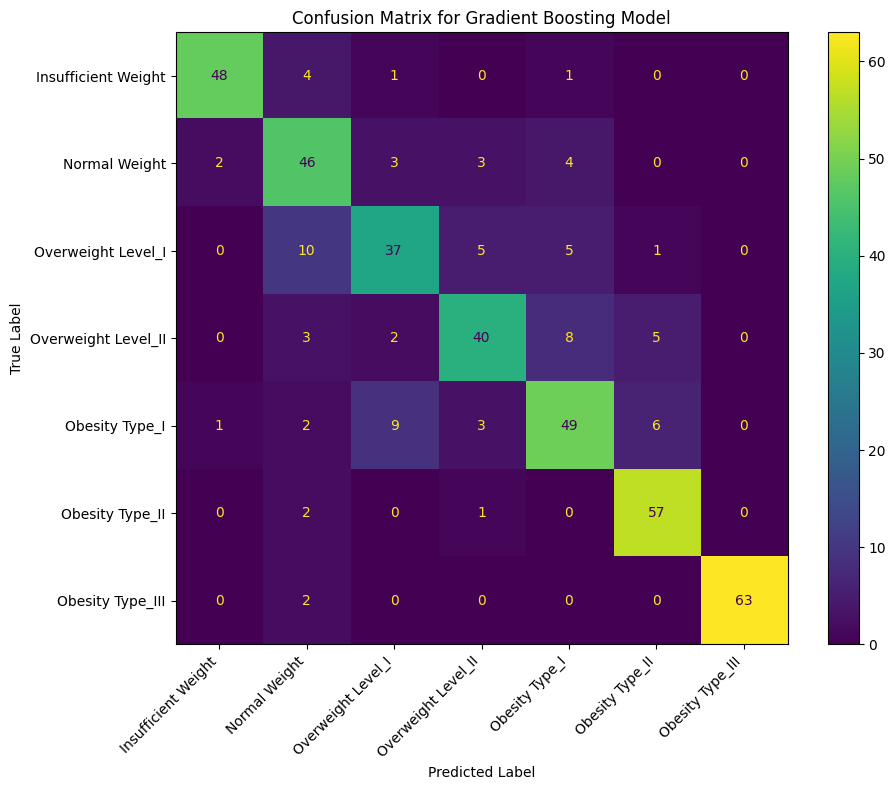

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions for the Gradient Boosting model
y_pred_gb = gb_model.predict(X_test_gb)

# Create the confusion matrix
cm = confusion_matrix(y_test_gb, y_pred_gb)

# Display the confusion matrix
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ObesityLabels)
disp.plot(cmap='viridis', ax=plt.gca())
plt.title('Confusion Matrix for Gradient Boosting Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Confusion Matrix for Tuned Gradient Boosting Model

This confusion matrix visually represents the performance of the tuned Gradient Boosting model. Each row shows the actual (true) obesity level, and each column shows the predicted obesity level. The numbers in each cell indicate the count of individuals:

*   **Diagonal elements:** Correct predictions (e.g., actual 'Obesity Type I' predicted as 'Obesity Type I').
*   **Off-diagonal elements:** Misclassifications (e.g., actual 'Obesity Type I' predicted as 'Overweight Level II').

A perfect model would have all values on the diagonal and zeros elsewhere.

### 5.6.1 Hyperparameter Tuning for Gradient Boosting

In [50]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

# Initialize GridSearchCV
# We use the existing gb_model as the estimator
grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=5, # 5-fold cross-validation
    scoring='accuracy', # Optimize for accuracy
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV to the training data
print("Starting GridSearchCV for Gradient Boosting...")
grid_search.fit(X_train_gb, y_train_gb)

print("\nBest parameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Get the best model
best_gb_model = grid_search.best_estimator_

# Evaluate the best model on the test set
y_pred_best_gb = best_gb_model.predict(X_test_gb)

print("\n--- Tuned Gradient Boosting Classifier Performance ---")
print(f"Accuracy:  {accuracy_score(y_test_gb, y_pred_best_gb):.4f}")
print("\n--- Detailed Classification Report (Tuned) ---")
print(classification_report(y_test_gb, y_pred_best_gb))

Starting GridSearchCV for Gradient Boosting...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best parameters found: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}
Best cross-validation accuracy: 0.825833582076449

--- Tuned Gradient Boosting Classifier Performance ---
Accuracy:  0.8274

--- Detailed Classification Report (Tuned) ---
              precision    recall  f1-score   support

         0.0       0.92      0.89      0.91        54
         1.0       0.64      0.76      0.69        58
         2.0       0.82      0.72      0.77        58
         3.0       0.80      0.71      0.75        58
         4.0       0.79      0.80      0.79        70
         5.0       0.85      0.93      0.89        60
         6.0       1.00      0.97      0.98        65

    accuracy                           0.83       423
   macro avg       0.83      0.83      0.83       423
weighted avg       0.83      0.83      0.83       423



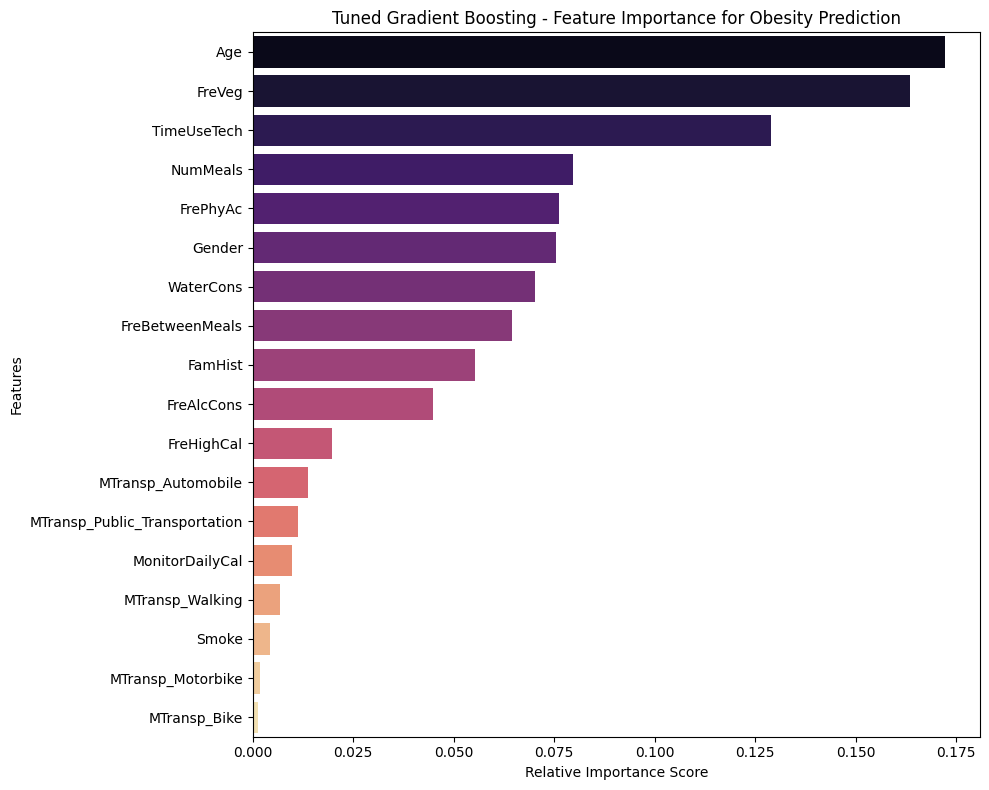

,Feature,Importance
1,Age,0.172327
4,FreVeg,0.163572
11,TimeUseTech,0.128901
5,NumMeals,0.079754
10,FrePhyAc,0.076197
0,Gender,0.075494
8,WaterCons,0.070364
6,FreBetweenMeals,0.064590
2,FamHist,0.055374
12,FreAlcCons,0.044812


In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract feature importances from the best tuned Gradient Boosting model
importances_gb = best_gb_model.feature_importances_
feature_names_gb = X_train_gb.columns

# Create a DataFrame for better visualization
feature_importance_df_gb = pd.DataFrame({
    'Feature': feature_names_gb,
    'Importance': importances_gb
}).sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feature_importance_df_gb, palette='magma', legend=False)
plt.title('Tuned Gradient Boosting - Feature Importance for Obesity Prediction')
plt.xlabel('Relative Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Display the exact numerical values
display(feature_importance_df_gb)

### Summary of Tuned Gradient Boosting Model

The hyperparameter tuning for the Gradient Boosting Classifier successfully improved its test accuracy to **82.74%**.

**Best Parameters Found:**
*   `learning_rate`: 0.1
*   `max_depth`: 4
*   `n_estimators`: 100

The feature importance analysis for this tuned model identified the following as the most impactful predictors of obesity:

1.  **Age**
2.  **Frequency of Vegetable Consumption (FreVeg)**
3.  **Time Used with Technology (TimeUseTech)**

These insights highlight the key demographic and lifestyle factors driving obesity classifications according to the optimized Gradient Boosting model.

<div class="alert alert-block alert-success">
<a id='explain'>
<font color = '#006400'>
    
# 6. Explainable AI</font>
</a>



* Logistic Regression
* Decision Trees
* Random Forest
* Support Vector Machines
* K-Nearest Neighbors
* Gradient Boosting methods

**Students should:**

* Select relevant features
* Train and evaluate multiple models
* Compare model performance
* Apply hyperparameter tuning
* Interpreting the most important predictors


**Performance should be evaluated using appropriate metrics such as:**
* Accuracy
* Precision
* Recall

**NObeyesdad** represents the obesity classification of each individual.

The categories include:

* Insufficient Weight
* Normal Weight
* Overweight Level I
* Overweight Level II
* Obesity Type I
* Obesity Type II
* Obesity Type III

You will use this variable as the target variable for predictive modeling.